<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [Initial Data Dictionary](#initial-data-dictionary)
- [Statistical and Associative Data Exploration](#statistical-and-associative-data-exploration)
    - [Explore protocol](#explore-protocol)
    - [Explore l7_proto](#explore-l7_proto)
    - [Explore in_bytes](#explore-in_bytes)
    - [Explore in_pkts](#explore-in_pkts)
    - [Explore out_bytes](#explore-out_bytes)
    - [Explore out_pkts](#explore-out_pkts)
    - [Explore tcp_flags](#explore-tcp_flags)
    - [Explore client_tcp_flags](#explore-client_tcp_flags)
    - [Explore server_tcp_flags](#explore-server_tcp_flags)
    - [Explore flow_duration_milliseconds](#explore-flow_duration_milliseconds)
    - [Explore duration_in](#explore-duration_in)
    - [Explore duration_out](#explore-duration_out)
    - [Explore min_ttl](#explore-min_ttl)
    - [Explore max_ttl](#explore-max_ttl)
    - [Explore longest_flow_pkt](#explore-longest_flow_pkt)
    - [Explore shortest_flow_pkt](#explore-shortest_flow_pkt)
    - [Explore min_ip_pkt_len](#explore-min_ip_pkt_len)
    - [Explore max_ip_pkt_len](#explore-max_ip_pkt_len)
    - [Explore src_to_dst_second_bytes](#explore-src_to_dst_second_bytes)
    - [Explore dst_to_src_second_bytes](#explore-dst_to_src_second_bytes)
    - [Explore retransmitted_in_bytes](#explore-retransmitted_in_bytes)
    - [Explore retransmitted_in_pkts](#explore-retransmitted_in_pkts)
    - [Explore retransmitted_out_bytes](#explore-retransmitted_out_bytes)
    - [Explore retransmitted_out_pkts](#explore-retransmitted_out_pkts)
    - [Explore src_to_dst_avg_throughput](#explore-src_to_dst_avg_throughput)
    - [Explore dst_to_src_avg_throughput](#explore-dst_to_src_avg_throughput)
    - [Explore num_pkts_up_to_128_bytes](#explore-num_pkts_up_to_128_bytes)
    - [Explore num_pkts_128_to_256_bytes](#explore-num_pkts_128_to_256_bytes)
    - [Explore num_pkts_256_to_512_bytes](#explore-num_pkts_256_to_512_bytes)
    - [Explore num_pkts_512_to_1024_bytes](#explore-num_pkts_512_to_1024_bytes)
    - [Explore num_pkts_1024_to_1514_bytes](#explore-num_pkts_1024_to_1514_bytes)
    - [Explore tcp_win_max_in](#explore-tcp_win_max_in)
    - [Explore tcp_win_max_out](#explore-tcp_win_max_out)
    - [Explore icmp_type](#explore-icmp_type)
    - [Explore icmp_ipv4_type](#explore-icmp_ipv4_type)
    - [Explore dns_query_id](#explore-dns_query_id)
    - [Explore dns_query_type](#explore-dns_query_type)
    - [Explore dns_ttl_answer](#explore-dns_ttl_answer)
    - [Explore ftp_command_ret_code](#explore-ftp_command_ret_code)
- [Final Data Dictionary](#final-data-dictionary)

</div>

### ORIENTATION:

This file demonstrates the exploration of the 'NF-UQ-NIDS-v2 Network Intrusion Detection Dataset' after cleaning and WITHOUT consideration of complex network ideology just yet.  The primary goal is to establish statistically significant and strongly associated features with the target feature 'attack' which has 21 different tags to include benign tags which make up the majority of the dataset.  These will then be used for Machine-Learning and Neural Network model training, testing, and performance evaluation to establish a baseline for later comparison with models using just complex network ideology and later a mixture of the two.

---

### IMPORTANT NOTE:

I have not taken any cybersecurity courses nor have a background in it so I apologize if there are better alternatives that I do not implement or am unaware of.  I have a very basic level of understanding from reading threads, research papers, and definitions of terminology relevant in the field.  Though Subject-Matter-Expertise (SME) would be very helpful and valuable during this stage in my opinion, I'm aware that there's the inherent risk of implementing bias into the model causing a poorly performing model.  For this reason-and my lack of SME-I will heavily rely on statistical methods to determine what should and shouldn't be implemented into model training.

---

### GENERAL STATISTICAL APPLICATION:

Due to the non-binary nature of the target feature 'attack' (21 categorical tags), I intend to rely on Analysis of Variance (ANOVA) related statistical methodologies.  ANOVA is primarily used when statistically comparing more than one group of information to help determine statistical significance and associativity of information.  Given the nature of the dataset, there are two distinct categories of data to consider in relation to the target feature:
1. Categorical Data ('object' and 'str' dtypes)
2. Numerical Data ('int' and 'float' dtypes)

To determine the statistical significance (i.e. whether or not the p-value is less than some alpha value that is typically set to 0.05), for categorical data I will use the chi-squared test and for numerical data I will use Kruskal Wallis H-Test since data like <code>bytes</code> are likely to be not normally distributed.

However, statistical significance does not mean it correlates to the target variable, it just means that the values of the feature are not random.  In other words, it should be effective for removing features with mathematical noise associated with them, but does not consider whether or not the feature actually is associated with the target feature name (Think of a port number.  Of course, the numbers aren't random and thus will be statistically significant, but what the numbers actually represent in relation to an attack for example is meaningless).  For this reason, I want to also consider statistical methods to prove associativity of features to the target feature, thus for categorical data I will use Cramer's V test and for numerical data I will use a Mutual Information test.

Overall, the intended implementation of statistical analysis is as follows:
- Categorical Data
    - Statistical Significance (Mathematic strength of information)
        - Chi-squared testing
        - Is significant if <code>p-value<=0.05</code>
    - Associativity to Target (Actual relationship to target)
        - Cramer's V
        - Strongly associated to target if <code>association>=0.50</code>
        - Mildly associated to target if <code>association>=0.30</code>
        - Weakly associated to target if <code>association>=0.10</code>
        - The above categories are to consider the very large depth of information representative in the dataset where it is likely that most things are only associated to a few specific target variables
- Numerical Data
    - Statistical Significance (Mathematic strength of information)
        - Kruskal Wallis H-Test
        - Is significant if <code>p-value<=0.05</code>
    - Associativity to Target (Actual relationship to target)
        - Mutual Information Test
        - Strongly associated to target if <code>association>=0.50</code>
        - Mildly associated to target if <code>association>=0.30</code>
        - Weakly associated to target if <code>association>=0.10</code>
        - The above categories are to consider the very large depth of information representative in the dataset where it is likely that most things are only associated to a few specific target variables
- If any feature is statistically significant <b>AND</b> has some sort of associative significance, then it will generally be used for ML and NN training unless otherwise noted

---

### EXPLORATION SUMMARY:

### SUMMARY:
- Inital Removal of Columns For Analysis(6)
    - Assumption of data poisoning
        - ipv4_src_addr
        - l4_src_port
        - ipv4_dst_addr
        - l4_dst_port
        - label
    - Useless data in relation to research scope
        - dataset
    - Target Variable
        - attack
- NOTE, EVERY FEATURE PASSED STATISTICAL ANALYSIS LIKELY DUE TO SIZE OF DATASET AND MULTIPLE DISTRIBUTIONS OF ATTACK.  For this reason, general understanding of feature, intuition, and associativity will be used to determine feature presence for model training
- Post Removal of Columns
    - 26 columns for removal (14 remain for training)
- Fully prepared dataset saved as 'prepared_normal_short.parquet'

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [5]:
import wrangle as w
import explore_normal_data as eND
import pandas as pd

/opt/anaconda3/envs/COMP3703/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Initial Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>

In [2]:
# Read in the dataset
df = pd.read_parquet('datasets/clean_short.parquet')

The dataset used is the `clean_short.parquet` which is 5% of the full dataset:
- Rows: 3,799,095
- Columns: 46
- Target: `attack` (21 Unique tags, distribution visualized below data dictionary)

| Feature Name | Dtype | Example | Description |
| :--- | :--- | :--- | :--- |
| **ipv4_src_addr** | `str` | 192.168.1.31, 192.168.1.34, 192.168.100.150 | The IPv4 address of the source host initiating the flow. |
| **l4_src_port** | `int64` | 38428, 37921, 39164 | The transport layer (Layer 4) source port number. |
| **ipv4_dst_addr** | `str` | 192.168.35.45, 192.168.1.49, 192.168.100.3 | The IPv4 address of the destination host receiving the flow. |
| **l4_dst_port** | `int64` | 443, 83, 80 | The transport layer (Layer 4) destination port number. |
| **protocol** | `int64` | 6, 17, 90 | The IP protocol number (e.g., 6 for TCP, 17 for UDP). |
| **l7_proto** | `float64` | 91.0, 0.0, 188.0 | The detected Application Layer (Layer 7) protocol (e.g., HTTP, DNS). |
| **in_bytes** | `int64` | 44, 56, 48 | Incoming bytes transferred from source to destination. |
| **in_pkts** | `int64` | 1, 2, 14 | Total number of incoming packets from source to destination. |
| **out_bytes** | `int64` | 0, 40, 764 | Outgoing bytes transferred from destination back to source. |
| **out_pkts** | `int64` | 0, 1, 9 | Total number of outgoing packets from destination back to source. |
| **tcp_flags** | `int64` | 2, 0, 22 | Cumulative bitwise-OR of all TCP flags observed in the flow. |
| **client_tcp_flags** | `int64` | 2, 0, 219 | Bitwise-OR of TCP flags sent specifically by the client (source). |
| **server_tcp_flags** | `int64` | 0, 20, 94 | Bitwise-OR of TCP flags sent specifically by the server (destination). |
| **flow_duration_milliseconds** | `int64` | 0, 4294013, 4294936 | The total elapsed time of the flow measured in milliseconds. |
| **duration_in** | `int64` | 0, 954, 719 | Duration of the active flow in the incoming direction. |
| **duration_out** | `int64` | 0, 16, 9 | Duration of the active flow in the outgoing direction. |
| **min_ttl** | `int64` | 0, 64, 100 | Minimum Time-to-Live (TTL) value observed in the flow. |
| **max_ttl** | `int64` | 0, 64, 100 | Maximum Time-to-Live (TTL) value observed in the flow. |
| **longest_flow_pkt** | `int64` | 44, 28, 48 | The size (in bytes) of the largest packet observed in the flow. |
| **shortest_flow_pkt** | `int64` | 44, 28, 40 | The size (in bytes) of the smallest packet observed in the flow. |
| **min_ip_pkt_len** | `int64` | 0, 40, 68 | The minimum IP packet length observed. |
| **max_ip_pkt_len** | `int64` | 44, 28, 48 | The maximum IP packet length observed. |
| **src_to_dst_second_bytes** | `float64` | 44.0, 2828.0, 48.0 | Average bytes per second sent from source to destination. |
| **dst_to_src_second_bytes** | `float64` | 0.0, 40.0, 764.0 | Average bytes per second sent from destination to source. |
| **retransmitted_in_bytes** | `int64` | 0, 140, 578 | Number of incoming bytes that were retransmitted. |
| **retransmitted_in_pkts** | `int64` | 0, 1, 2 | Number of incoming packets that were retransmitted. |
| **retransmitted_out_bytes** | `int64` | 0, 1419, 4820 | Number of outgoing bytes that were retransmitted. |
| **retransmitted_out_pkts** | `int64` | 0, 4, 6 | Number of outgoing packets that were retransmitted. |
| **src_to_dst_avg_throughput** | `int64` | 352000, 224000, 384000 | Average bits per second sent from source to destination. |
| **dst_to_src_avg_throughput** | `int64` | 0, 320000, 6112000 | Average bits per second sent from destination to source. |
| **num_pkts_up_to_128_bytes** | `int64` | 1, 2, 19 | Count of packets in the flow with size ≤ 128 bytes. |
| **num_pkts_128_to_256_bytes** | `int64` | 0, 1, 2 | Count of packets in the flow with size between 128 and 256 bytes. |
| **num_pkts_256_to_512_bytes** | `int64` | 0, 2, 1 | Count of packets in the flow with size between 256 and 512 bytes. |
| **num_pkts_512_to_1024_bytes** | `int64` | 0, 1, 2 | Count of packets in the flow with size between 512 and 1024 bytes. |
| **num_pkts_1024_to_1514_bytes** | `int64` | 0, 1, 3 | Count of packets in the flow with size between 1024 and 1514 bytes. |
| **tcp_win_max_in** | `int64` | 1024, 0, 4096 | Maximum TCP window size observed for incoming traffic. |
| **tcp_win_max_out** | `int64` | 0, 64000, 29200 | Maximum TCP window size observed for outgoing traffic. |
| **icmp_type** | `int64` | 0, 35840, 16896 | ICMP message type and code encoded as a decimal. |
| **icmp_ipv4_type** | `int64` | 0, 140, 66 | Specific ICMP Type field value for IPv4 traffic. |
| **dns_query_id** | `int64` | 0, 33190, 30688 | The transaction ID for DNS queries. |
| **dns_query_type** | `int64` | 0, 28, 1 | The type of DNS record requested (e.g., 1 for A, 28 for AAAA). |
| **dns_ttl_answer** | `int64` | 0, 60, 20 | The Time-to-Live (TTL) value from the DNS response. |
| **ftp_command_ret_code** | `float64` | 0.0, 125.0, 230.0 | The three-digit return code from an FTP command. |
| **label** | `int64` | 1, 0 | Binary indicator of traffic: 0 for Benign, 1 for Attack. |
| **attack** | `str` | scanning, benign, ddos, ... | Categorical name of the specific attack type (21 unique tags). |
| **dataset** | `str` | nf-ton-iot-v2, nf-bot-iot-v2, ... | The original source dataset from which the flow was extracted. |

/Users/manupfool/Desktop/University_of_Denver/inprogress_courses/COMP3703/final/explore_normal_data.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=labels, palette='viridis')


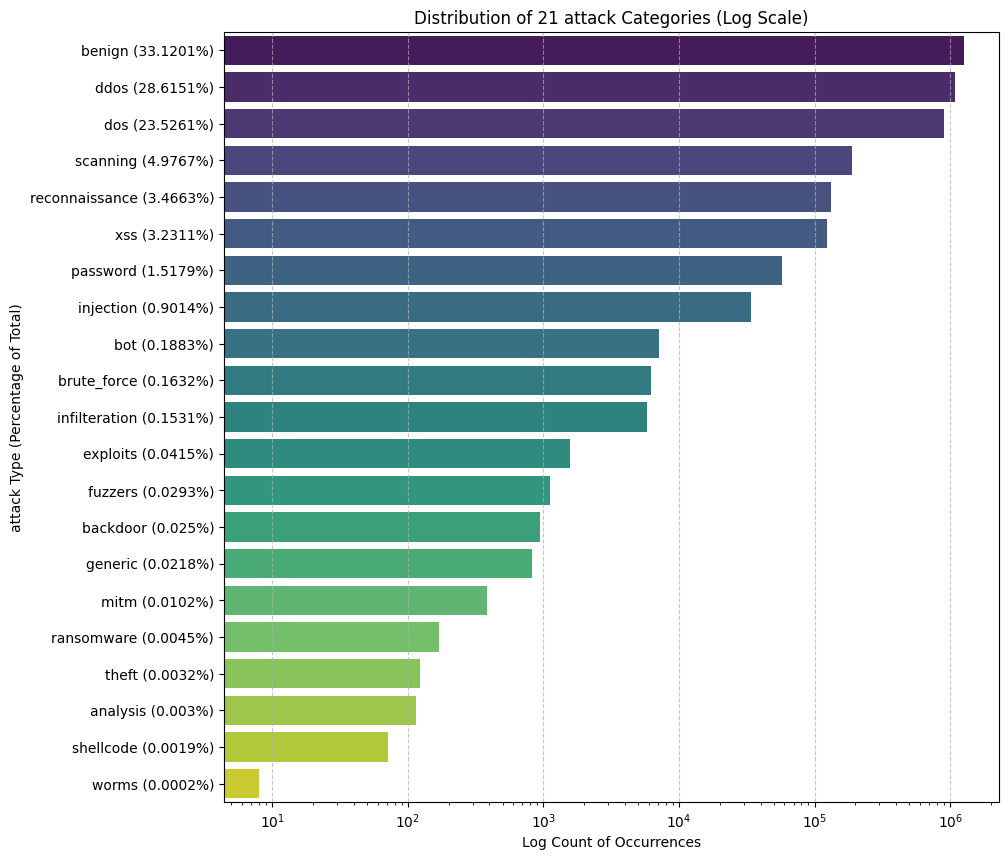

In [3]:
# Visualize target distribution
eND.vis_target_distribution(df)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Statistical and Associative Data Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

### SUMMARY:
- Inital Removal of Columns For Analysis(6)
    - Assumption of data poisoning
        - ipv4_src_addr
        - l4_src_port
        - ipv4_dst_addr
        - l4_dst_port
        - label
    - Useless data in relation to research scope
        - dataset
    - Target Variable
        - attack
- NOTE, EVERY FEATURE PASSED STATISTICAL ANALYSIS LIKELY DUE TO SIZE OF DATASET AND MULTIPLE DISTRIBUTIONS OF ATTACK.  For this reason, general understanding of feature, intuition, and associativity will be used to determine feature presence for model training
- Analysis findings for every feature
    - protocol // REMOVE // Low association, distribution appears arbitrary
    - l7_proto // REMOVE // Mod association, distribution biased
    - in_bytes // KEEP // High association, distribution appears to have a trend
    - in_pkts // REMOVE // Mod association, likely similar info with in_bytes
    - out_bytes // KEEP // High association, distribution appears to have a trend
    - out_pkts // REMOVE // Mod association, likely similar info with out_bytes
    - tcp_flags // REMOVE // Low association, distribution biased
    - client_tcp_flags // REMOVE // Low association, distribution biased
    - server_tcp_flags // REMOVE // Low association, distribution biased
    - flow_duration_milliseconds // KEEP // High association, distribution appears to have a trend
    - duration_in // KEEP // High association, distribution appears to have a trend
    - duration_out // REMOVE // Minimal association
    - min_ttl // KEEP // High association, distribution appears to have a trend
    - max_ttl // KEEP // High association, distribution appears to have a trend
    - longest_flow_pkt // KEEP // High association, distribution appears to have a trend
    - shortest_flow_pkt // KEEP // High association, distribution appears to have a trend
    - min_ip_pkt_len // REMOVE // Mod association, but max_ip_pkt_len has much stronger association
    - max_ip_pkt_len // KEEP // High association, distribution appears to have a trend
    - src_to_dst_second_bytes // REMOVE // Minimal association, VERY LARGE VALUES (TB)
    - dst_to_src_second_bytes // REMOVE // Zero association
    - retransmitted_in_bytes // REMOVE // Low association
    - retransmitted_in_pkts // REMOVE // Low association
    - retransmitted_out_bytes // REMOVE // Minimal association
    - retransmitted_out_pkts // REMOVE // Minimal association
    - src_to_dst_avg_throughput // KEEP // High association, distribution appears to have a trend
    - dst_to_src_avg_throughput // REMOVE // High association, likely similar info with src_to_dst_avg_throughput
    - num_pkts_up_to_128_bytes // KEEP // High association, distribution appears to have a trend
    - num_pkts_128_to_256_bytes // KEEP // Mod association, distribution appears to have a trend
    - num_pkts_256_to_512_bytes // REMOVE // Minimal association
    - num_pkts_512_to_1024_bytes // REMOVE // Minimal association
    - num_pkts_1024_to_1514_bytes // REMOVE // Low association
    - tcp_win_max_in // KEEP // High association, distribution appears to have a trend
    - tcp_win_max_out // REMOVE // Mod association, likely similar info with tcp_win_max_in
    - icmp_type // REMOVE // Low association, distribution biased
    - icmp_ipv4_type // REMOVE // Low association, distribution biased
    - dns_query_id // REMOVE // Low association, distribution biased
    - dns_query_type // REMOVE // Low association, distribution biased
    - dns_ttl_answer // REMOVE // Low association, distribution biased
    - ftp_command_ret_code // REMOVE // Minimal association, distribution biased
- Post Removal of Columns
    - 26 columns for removal (14 remain for training)

---
##### Explore protocol

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Low association, distribution appears arbitrary

protocol IS statistically significant with attack!
Statistic: 3565559.6633
P-Val: 0.0000
P-Threshold: 0.0500


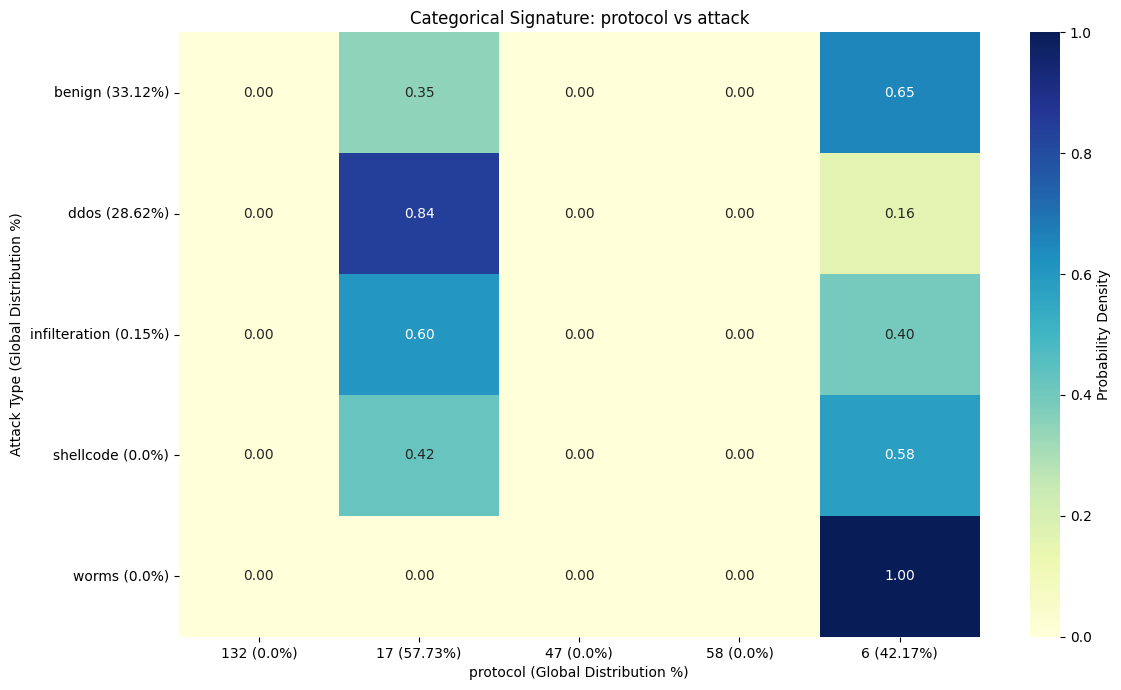

protocol has LOW ASSOCATION with attack!


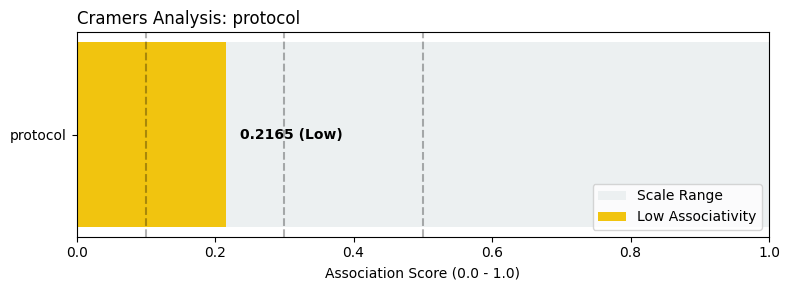

In [24]:
eND.analyze_statistical_significance_and_associativity(df, 'protocol', is_object_feature=True)

---
##### Explore l7_proto

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Mod association, distribution biased

l7_proto IS statistically significant with attack!
Statistic: 11530438.0452
P-Val: 0.0000
P-Threshold: 0.0500


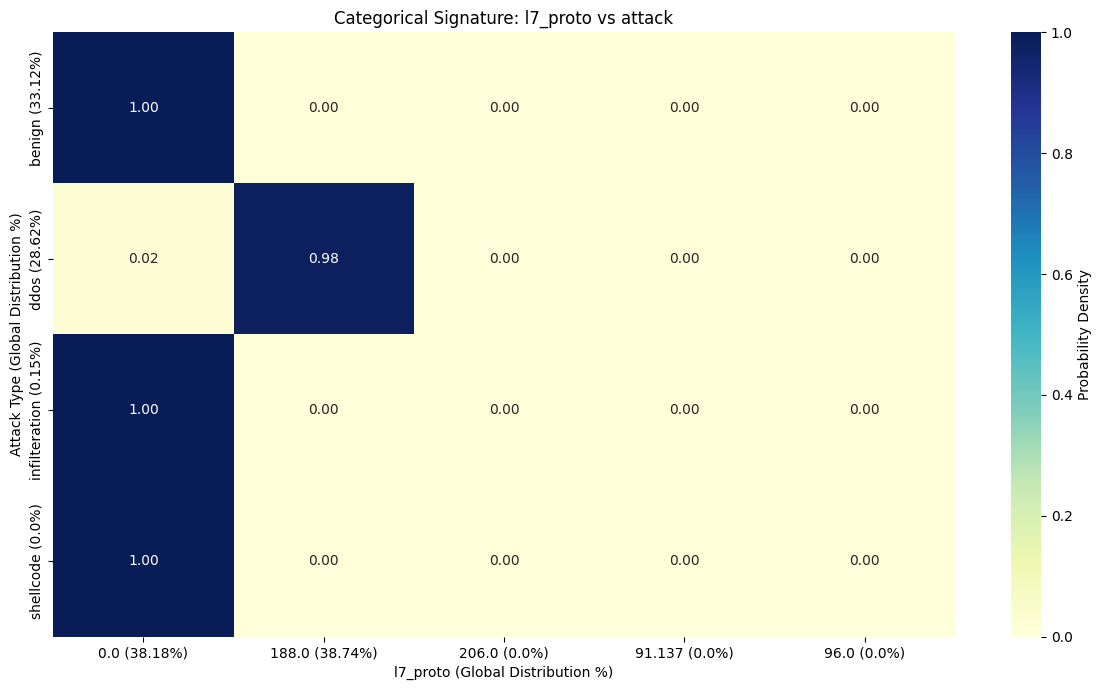

l7_proto is MODERATE ASSOCIATION with attack!


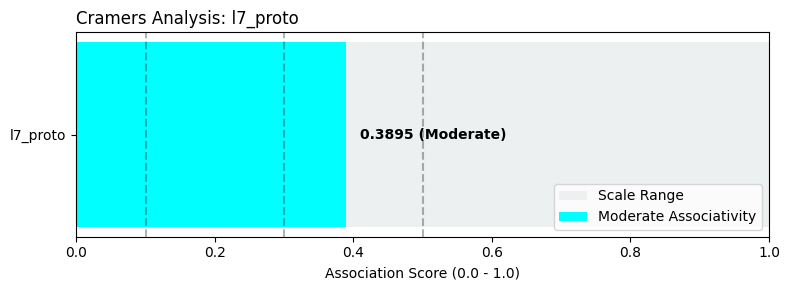

In [3]:
eND.analyze_statistical_significance_and_associativity(df, 'l7_proto', is_object_feature=True)

---
##### Explore in_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

in_bytes IS statistically significant with attack!
Statistic: 1137231.4596
P-Val: 0.0000
P-Threshold: 0.0500



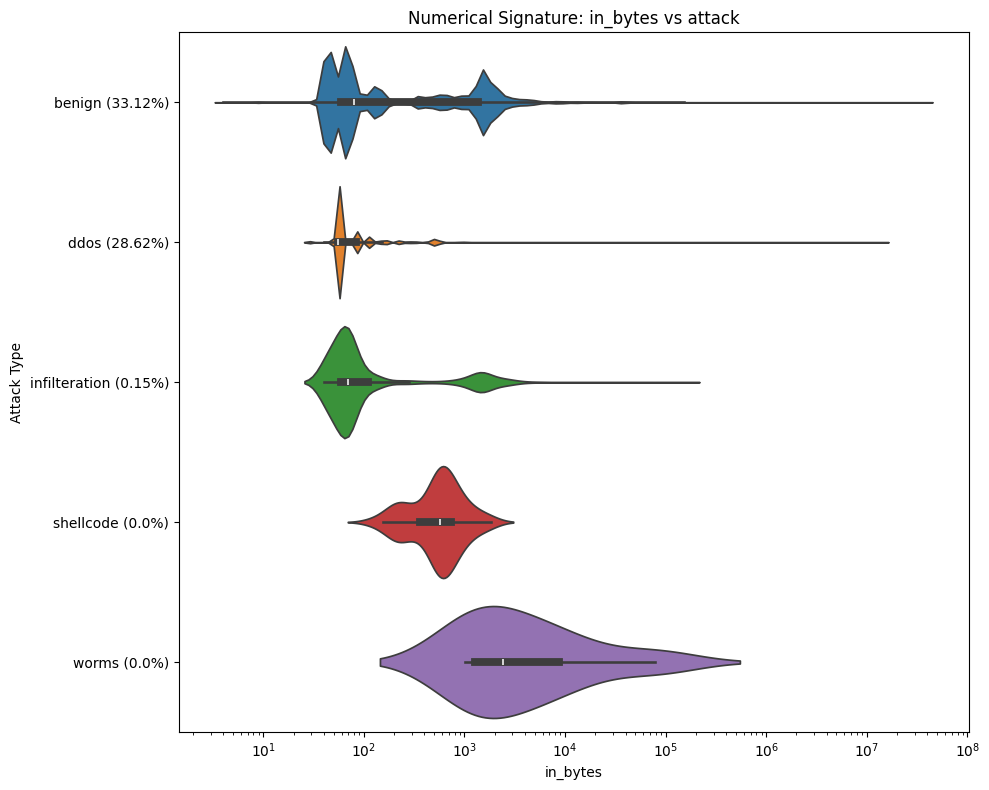

in_bytes has HIGH ASSOCIATION with attack!


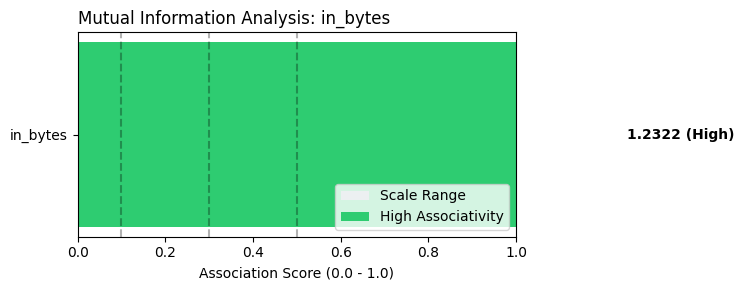

In [4]:
eND.analyze_statistical_significance_and_associativity(df, 'in_bytes')

---
##### Explore in_pkts

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Mod association, likely similar info with in_bytes

in_pkts IS statistically significant with attack!
Statistic: 535252.2432
P-Val: 0.0000
P-Threshold: 0.0500



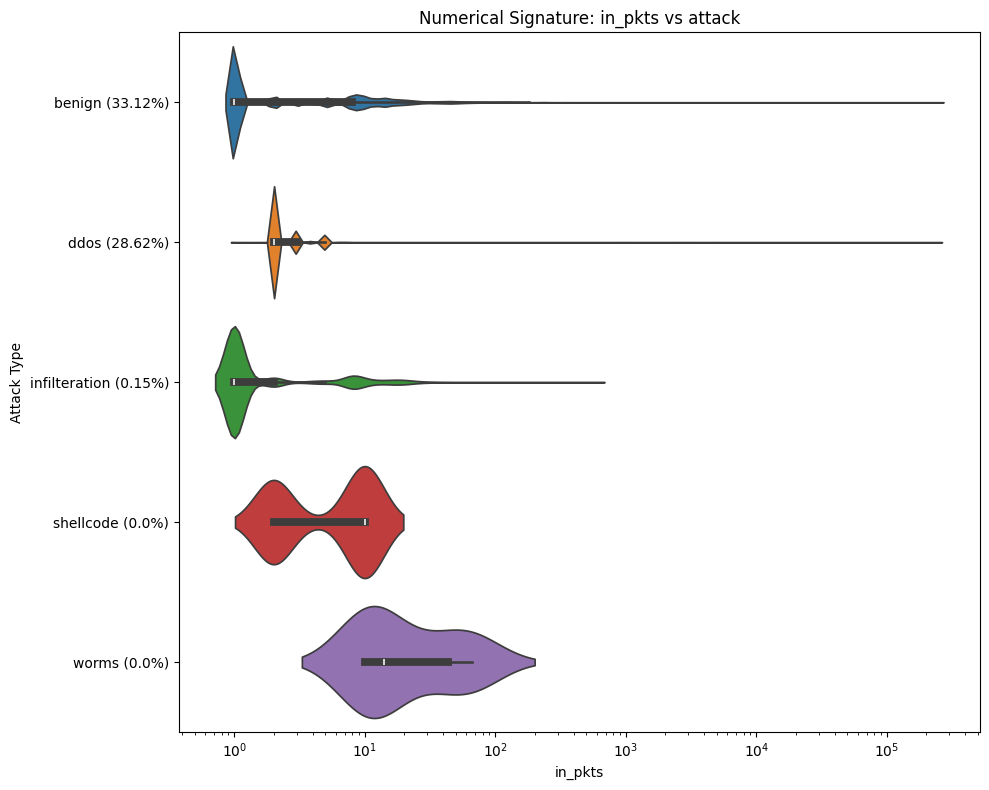

in_pkts is MODERATE ASSOCIATION with attack!


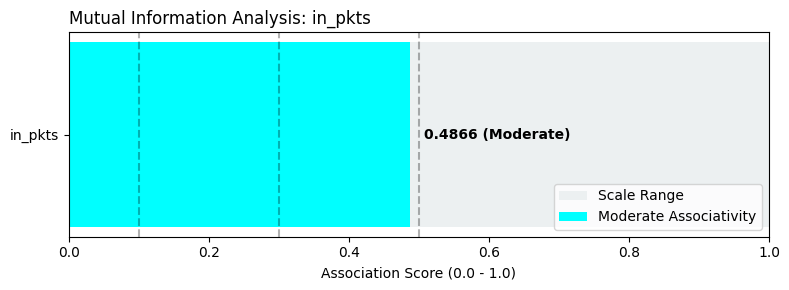

In [5]:
eND.analyze_statistical_significance_and_associativity(df, 'in_pkts')

---
##### Explore out_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

out_bytes IS statistically significant with attack!
Statistic: 1785838.9741
P-Val: 0.0000
P-Threshold: 0.0500



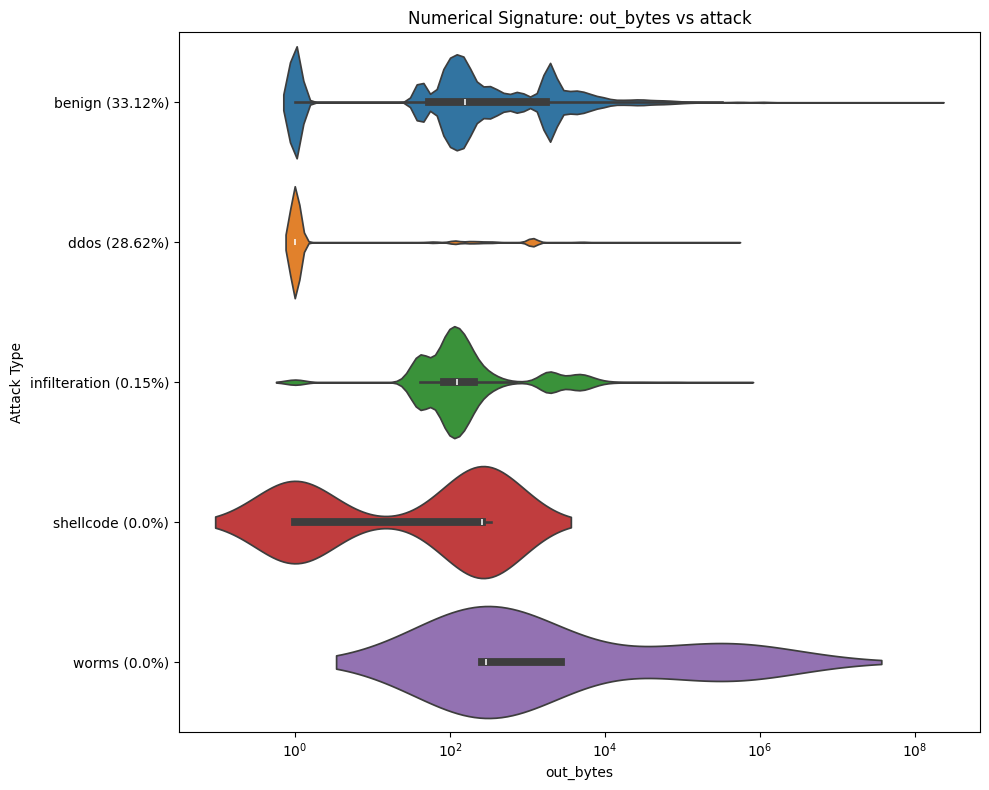

out_bytes has HIGH ASSOCIATION with attack!


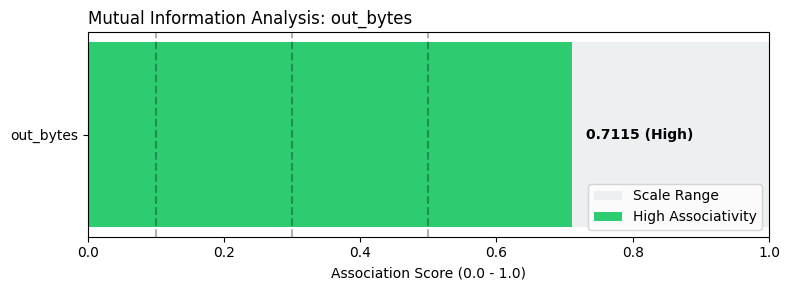

In [3]:
eND.analyze_statistical_significance_and_associativity(df, 'out_bytes')

---
##### Explore out_pkts

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Mod association, likely similar info with out_bytes

out_pkts IS statistically significant with attack!
Statistic: 1674859.4181
P-Val: 0.0000
P-Threshold: 0.0500



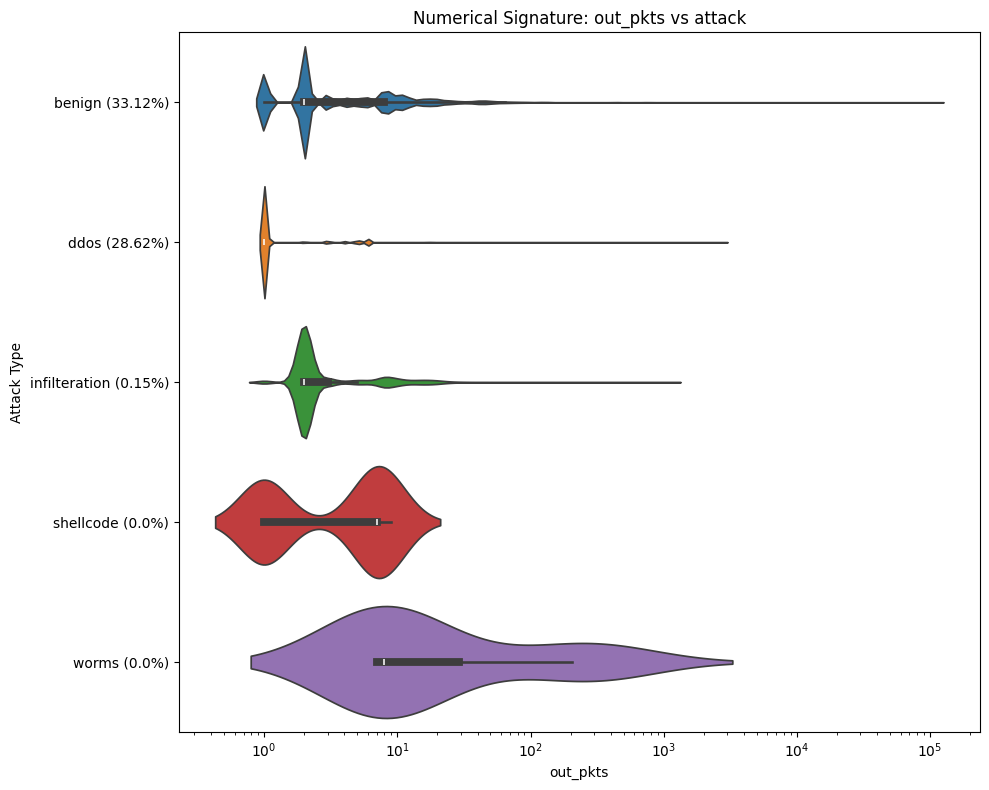

out_pkts is MODERATE ASSOCIATION with attack!


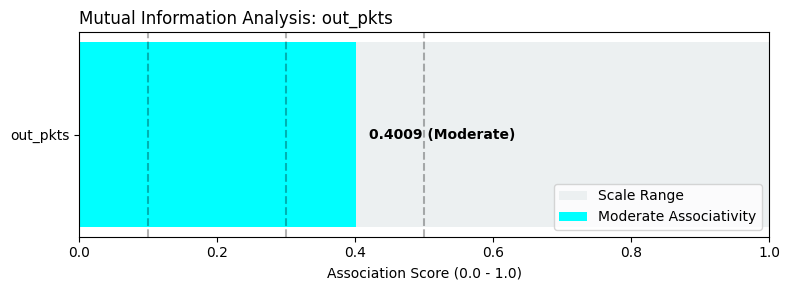

In [4]:
eND.analyze_statistical_significance_and_associativity(df, 'out_pkts')

---
##### Explore tcp_flags

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC:
- Low association, distribution biased

tcp_flags IS statistically significant with attack!
Statistic: 5937254.5272
P-Val: 0.0000
P-Threshold: 0.0500


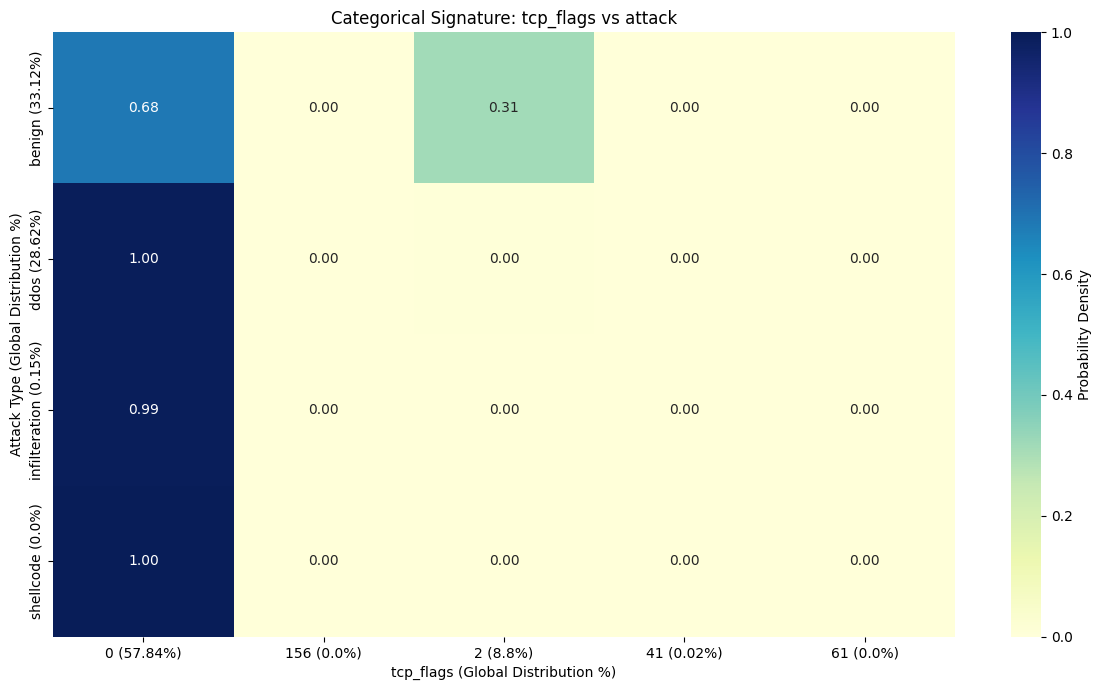

tcp_flags has LOW ASSOCATION with attack!


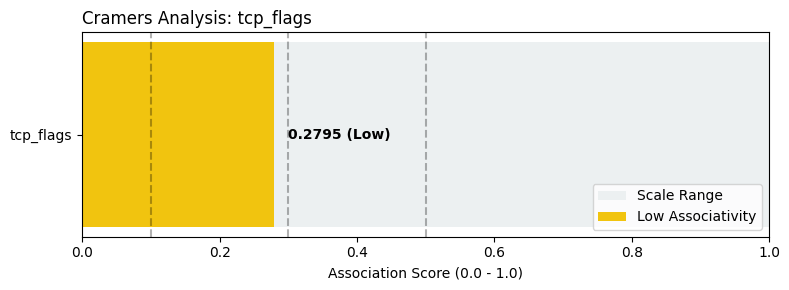

In [5]:
eND.analyze_statistical_significance_and_associativity(df, 'tcp_flags', is_object_feature=True)

---
##### Explore client_tcp_flags

- [Back to Table of Contents](#table-of-contents)

VERDICT:REMOVE

MISC: 
- Low association, distribution biased

client_tcp_flags IS statistically significant with attack!
Statistic: 5588350.8178
P-Val: 0.0000
P-Threshold: 0.0500


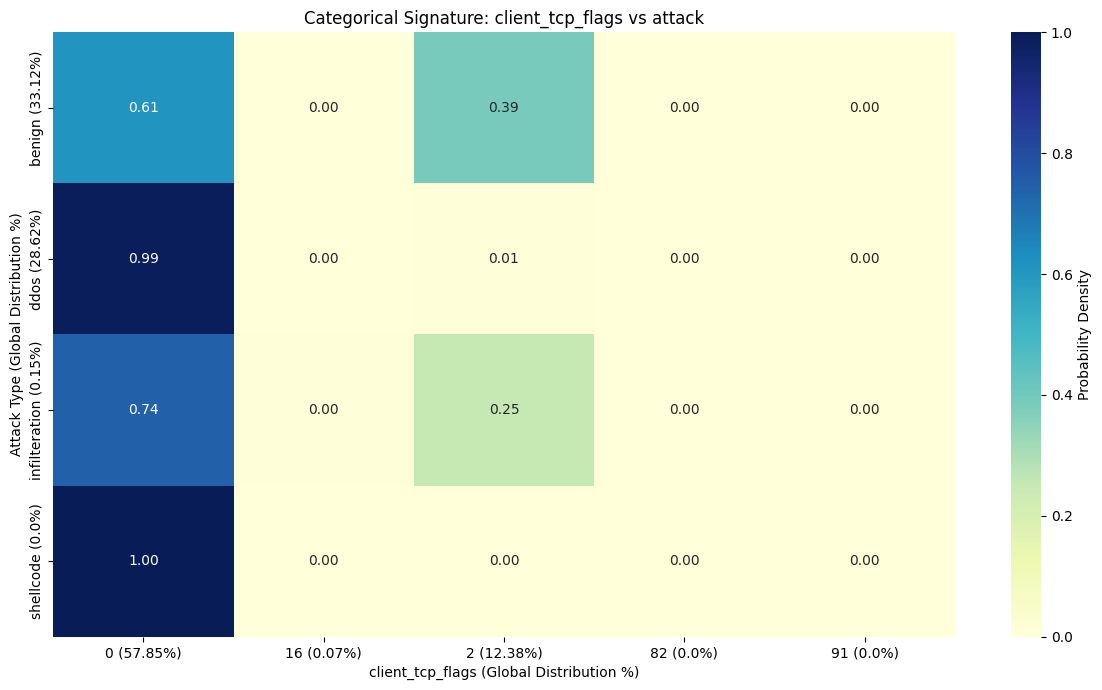

client_tcp_flags has LOW ASSOCATION with attack!


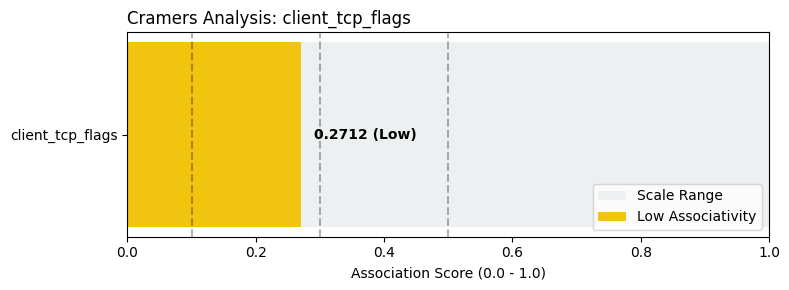

In [6]:
eND.analyze_statistical_significance_and_associativity(df, 'client_tcp_flags', is_object_feature=True)

---
##### Explore server_tcp_flags

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: Low association, distribution biased

server_tcp_flags IS statistically significant with attack!
Statistic: 2735273.0694
P-Val: 0.0000
P-Threshold: 0.0500


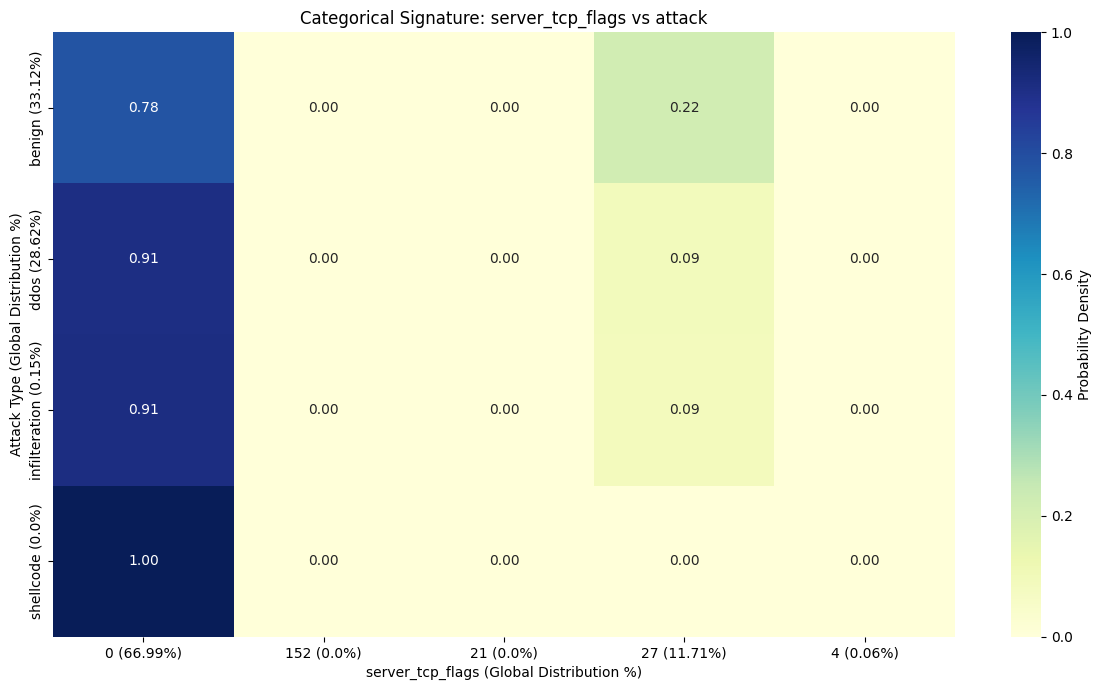

server_tcp_flags has LOW ASSOCATION with attack!


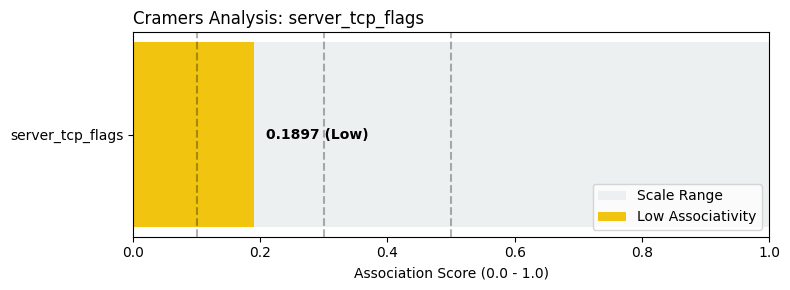

In [7]:
eND.analyze_statistical_significance_and_associativity(df, 'server_tcp_flags', is_object_feature=True)

---
##### Explore flow_duration_milliseconds

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

flow_duration_milliseconds IS statistically significant with attack!
Statistic: 2166407.7579
P-Val: 0.0000
P-Threshold: 0.0500



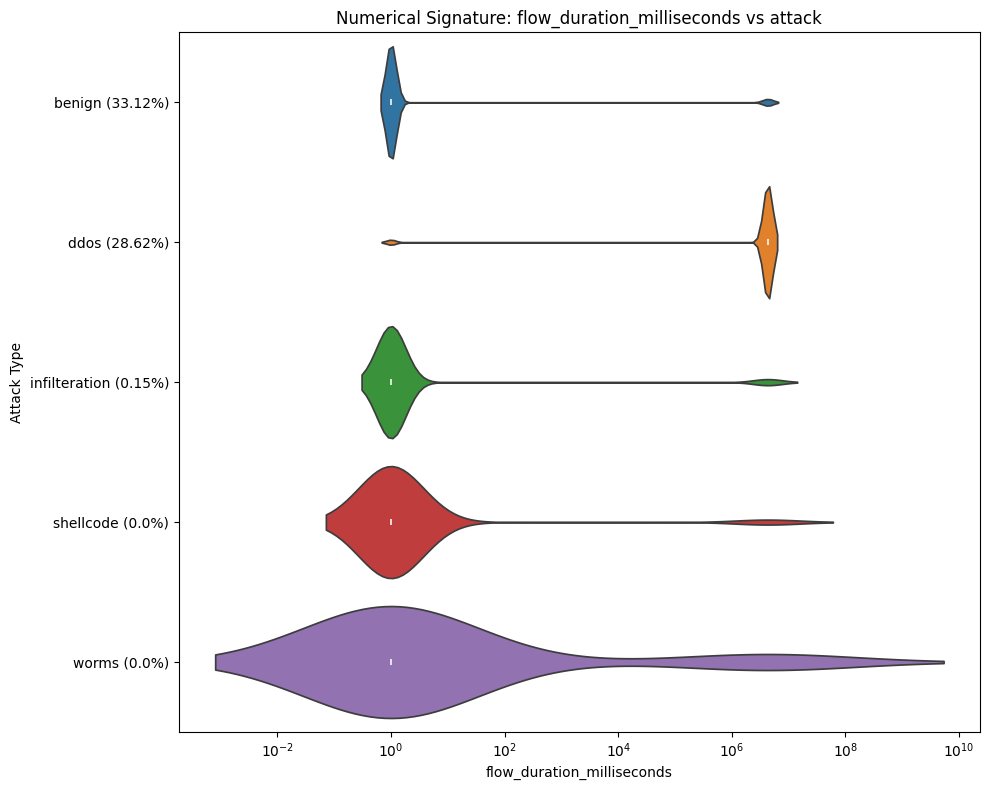

flow_duration_milliseconds has HIGH ASSOCIATION with attack!


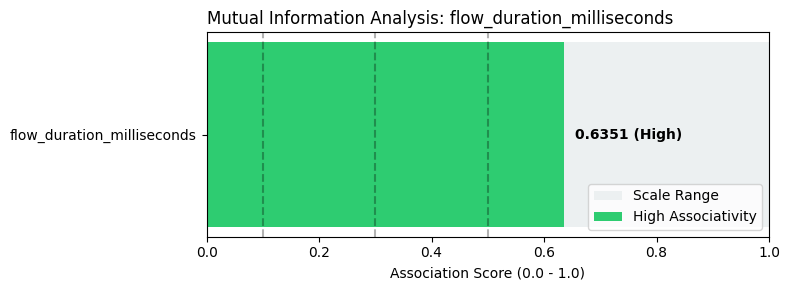

In [8]:
eND.analyze_statistical_significance_and_associativity(df, 'flow_duration_milliseconds')

---
##### Explore duration_in

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

duration_in IS statistically significant with attack!
Statistic: 2648492.8730
P-Val: 0.0000
P-Threshold: 0.0500



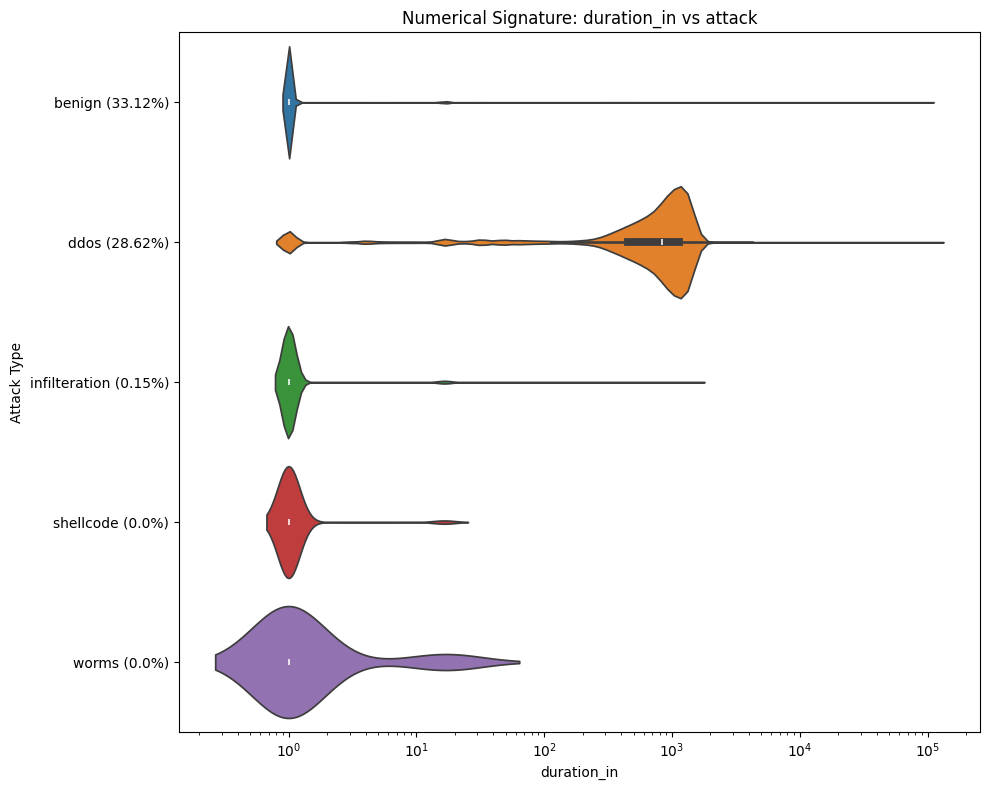

duration_in has HIGH ASSOCIATION with attack!


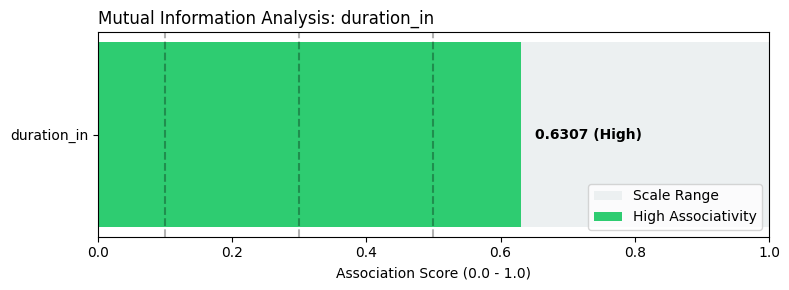

In [9]:
eND.analyze_statistical_significance_and_associativity(df, 'duration_in')

---
##### Explore duration_out

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Minimal association

duration_out IS statistically significant with attack!
Statistic: 237794.1069
P-Val: 0.0000
P-Threshold: 0.0500



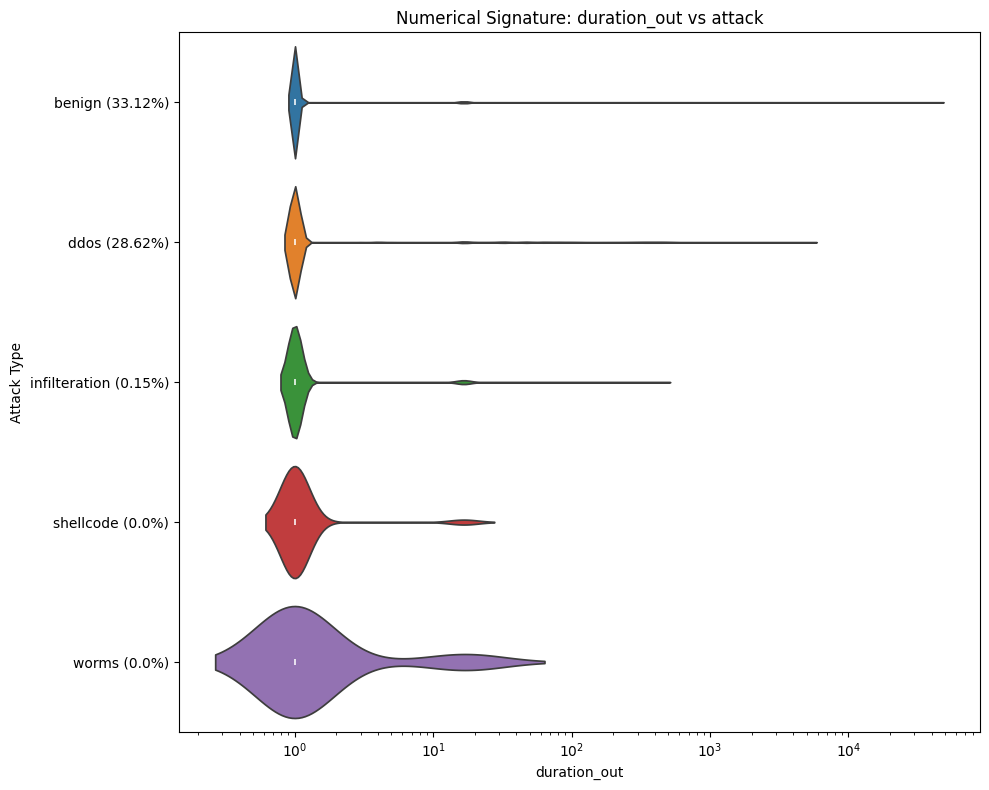

duration_out has MINIMAL ASSOCATION with attack!


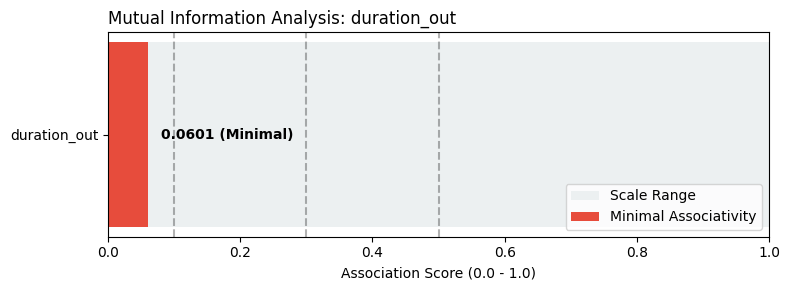

In [10]:
eND.analyze_statistical_significance_and_associativity(df, 'duration_out')

---
##### Explore min_ttl

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

min_ttl IS statistically significant with attack!
Statistic: 637769.6065
P-Val: 0.0000
P-Threshold: 0.0500



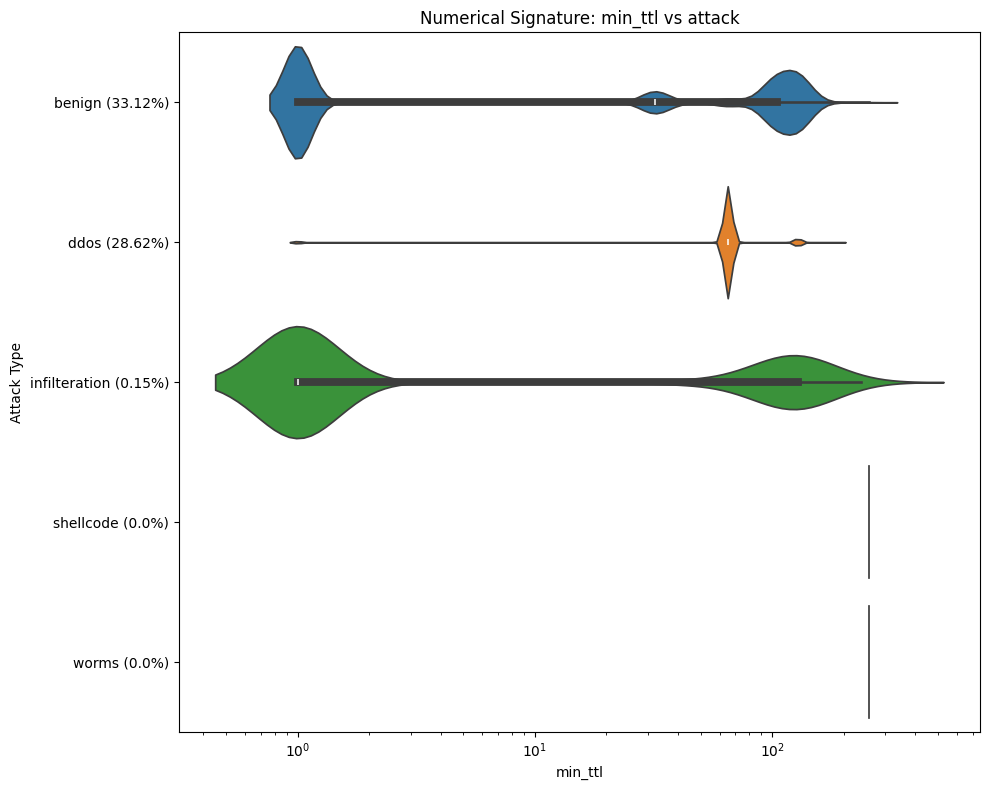

min_ttl has HIGH ASSOCIATION with attack!


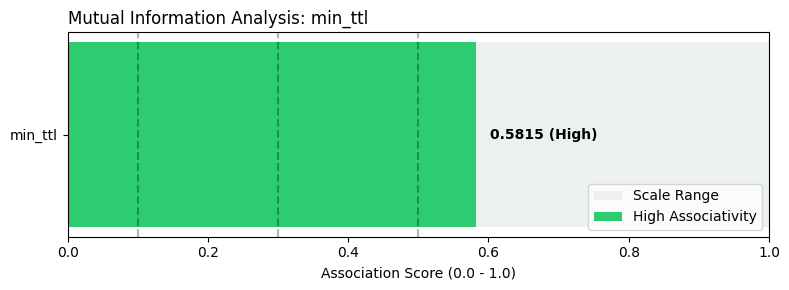

In [11]:
eND.analyze_statistical_significance_and_associativity(df, 'min_ttl')

---
##### Explore max_ttl

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

max_ttl IS statistically significant with attack!
Statistic: 636871.3173
P-Val: 0.0000
P-Threshold: 0.0500



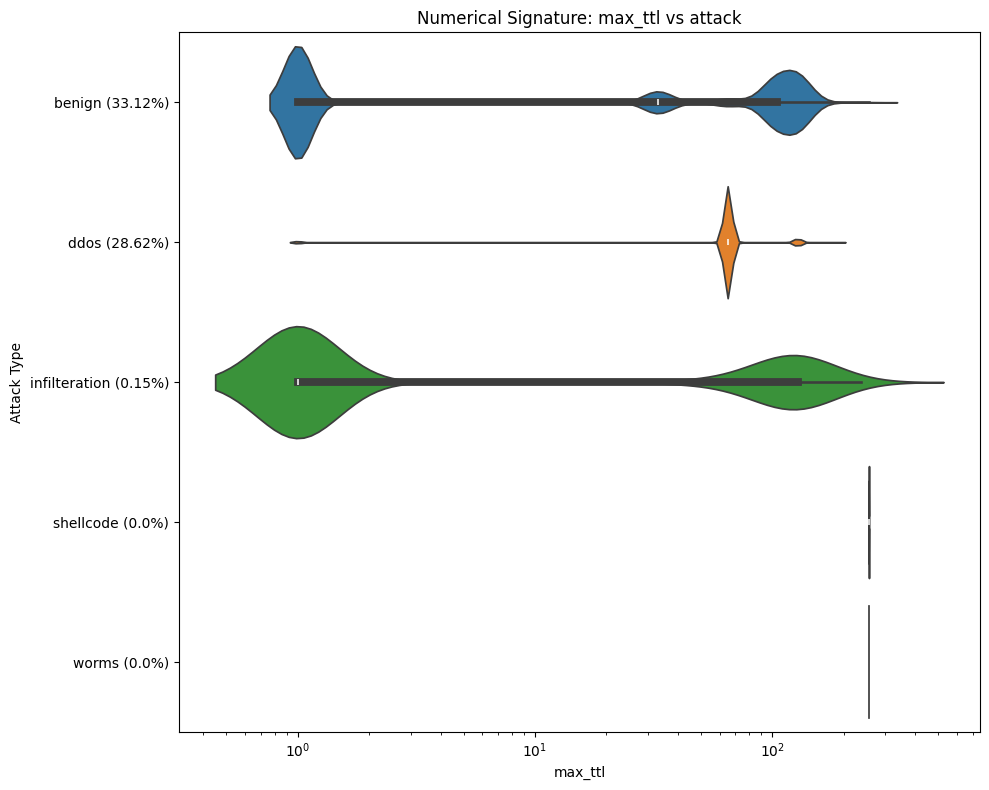

max_ttl has HIGH ASSOCIATION with attack!


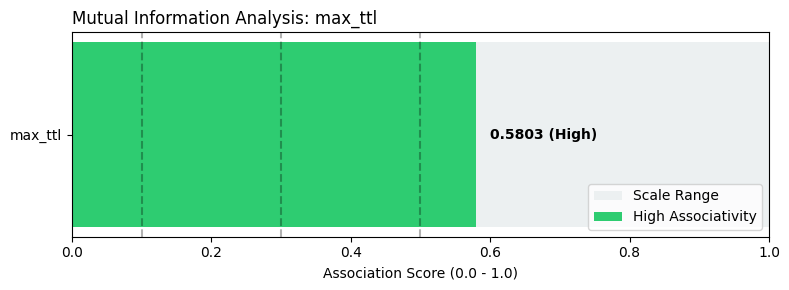

In [12]:
eND.analyze_statistical_significance_and_associativity(df, 'max_ttl')

---
##### Explore longest_flow_pkt

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

longest_flow_pkt IS statistically significant with attack!
Statistic: 1853038.4930
P-Val: 0.0000
P-Threshold: 0.0500



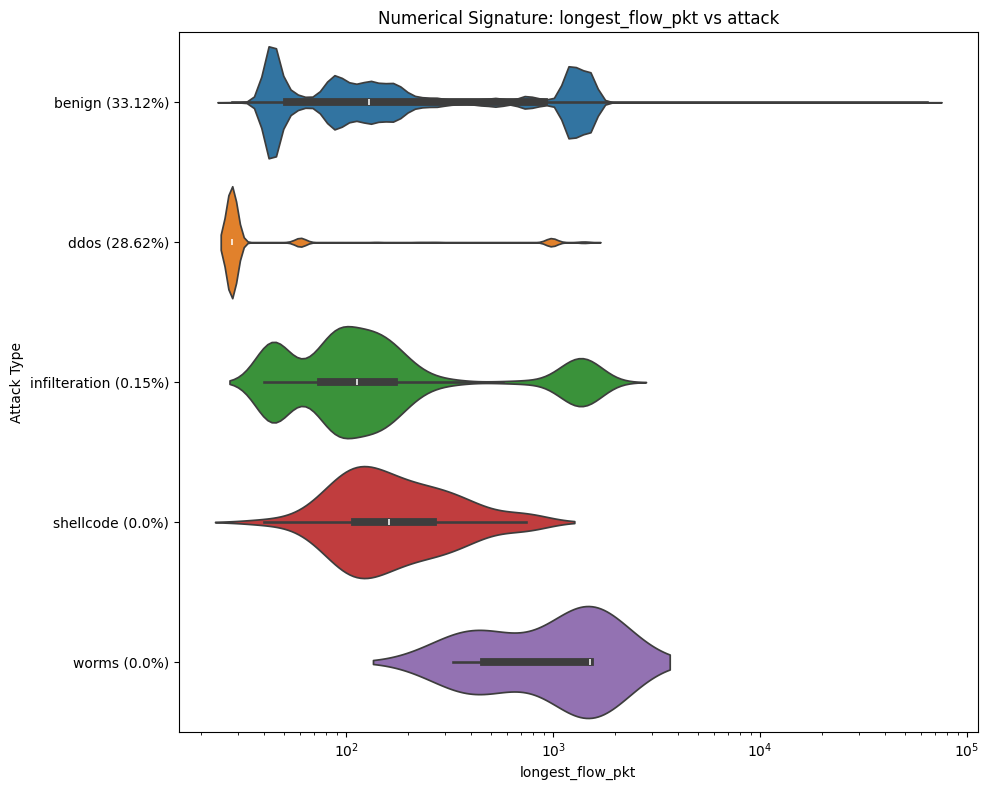

longest_flow_pkt has HIGH ASSOCIATION with attack!


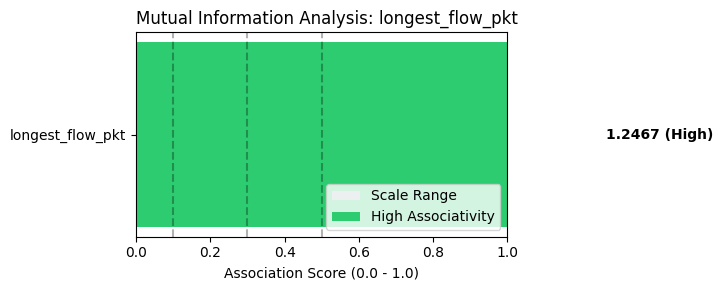

In [13]:
eND.analyze_statistical_significance_and_associativity(df, 'longest_flow_pkt')

---
##### Explore shortest_flow_pkt

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

shortest_flow_pkt IS statistically significant with attack!
Statistic: 2577043.2505
P-Val: 0.0000
P-Threshold: 0.0500



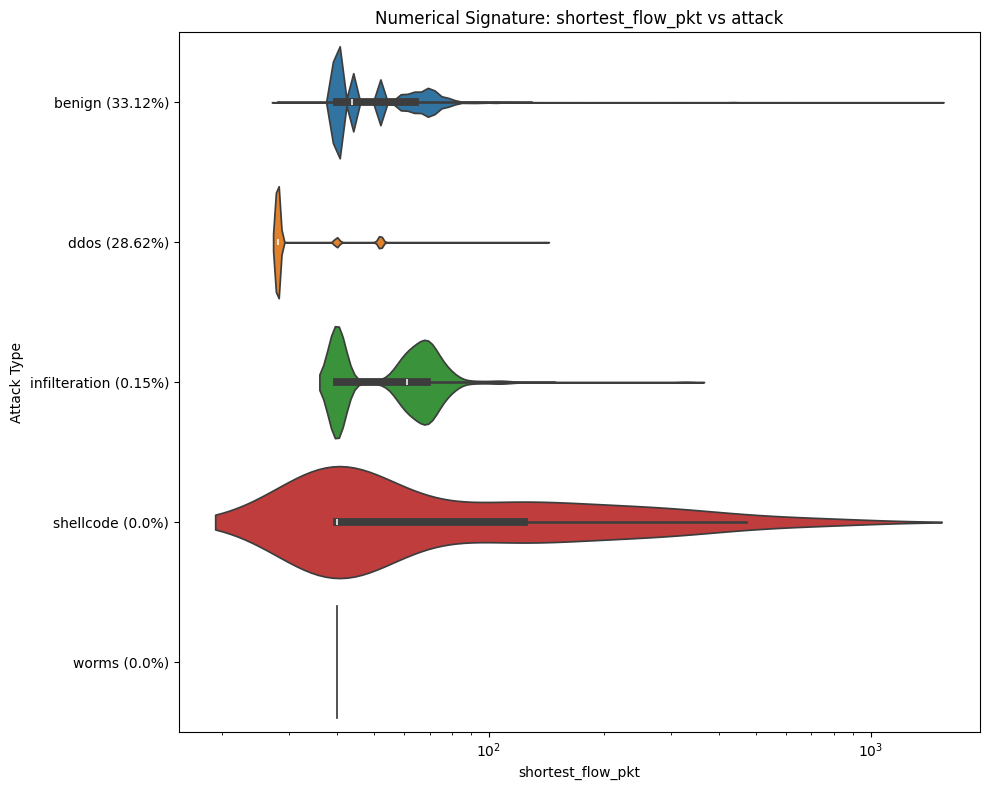

shortest_flow_pkt has HIGH ASSOCIATION with attack!


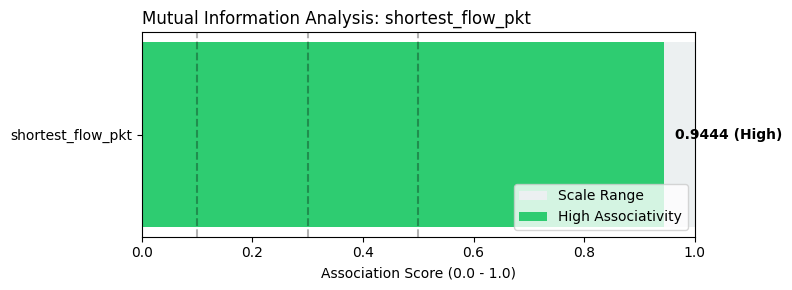

In [14]:
eND.analyze_statistical_significance_and_associativity(df, 'shortest_flow_pkt')

---
##### Explore min_ip_pkt_len

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Mod association, but max_ip_pkt_len has much stronger association

min_ip_pkt_len IS statistically significant with attack!
Statistic: 1750324.4357
P-Val: 0.0000
P-Threshold: 0.0500



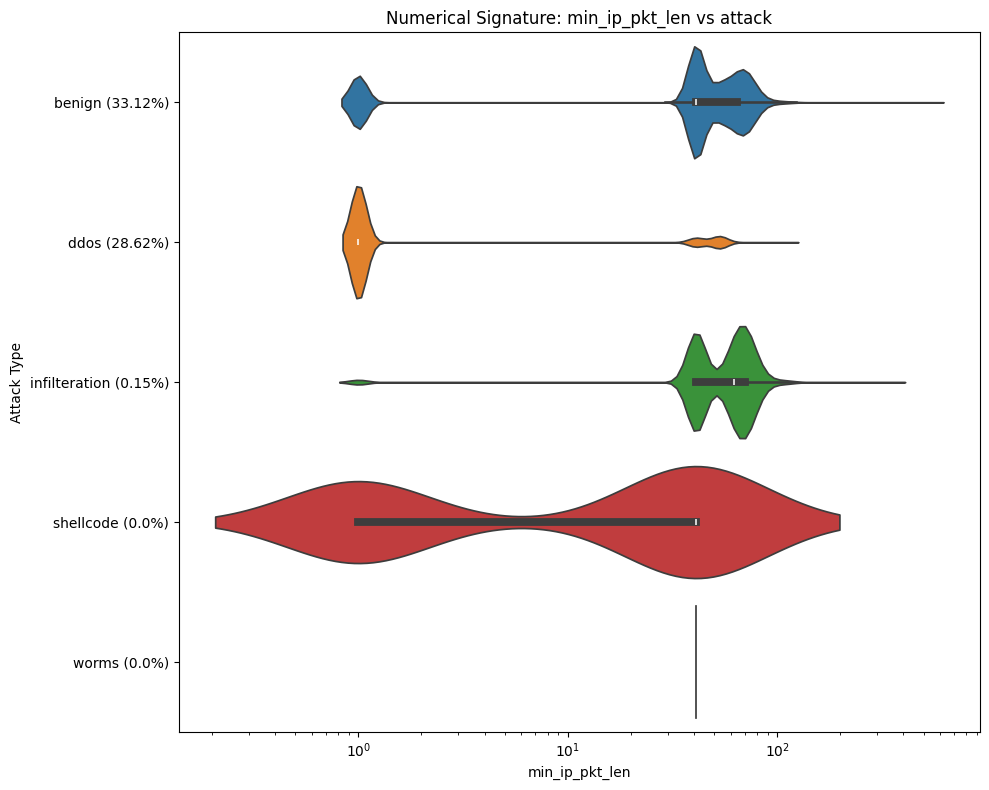

min_ip_pkt_len is MODERATE ASSOCIATION with attack!


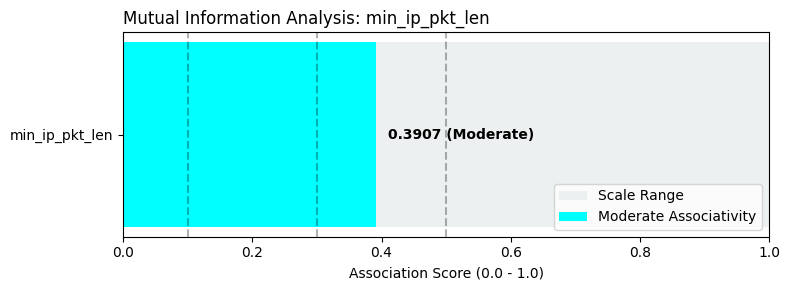

In [15]:
eND.analyze_statistical_significance_and_associativity(df, 'min_ip_pkt_len')

---
##### Explore max_ip_pkt_len

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

max_ip_pkt_len IS statistically significant with attack!
Statistic: 1853038.4930
P-Val: 0.0000
P-Threshold: 0.0500



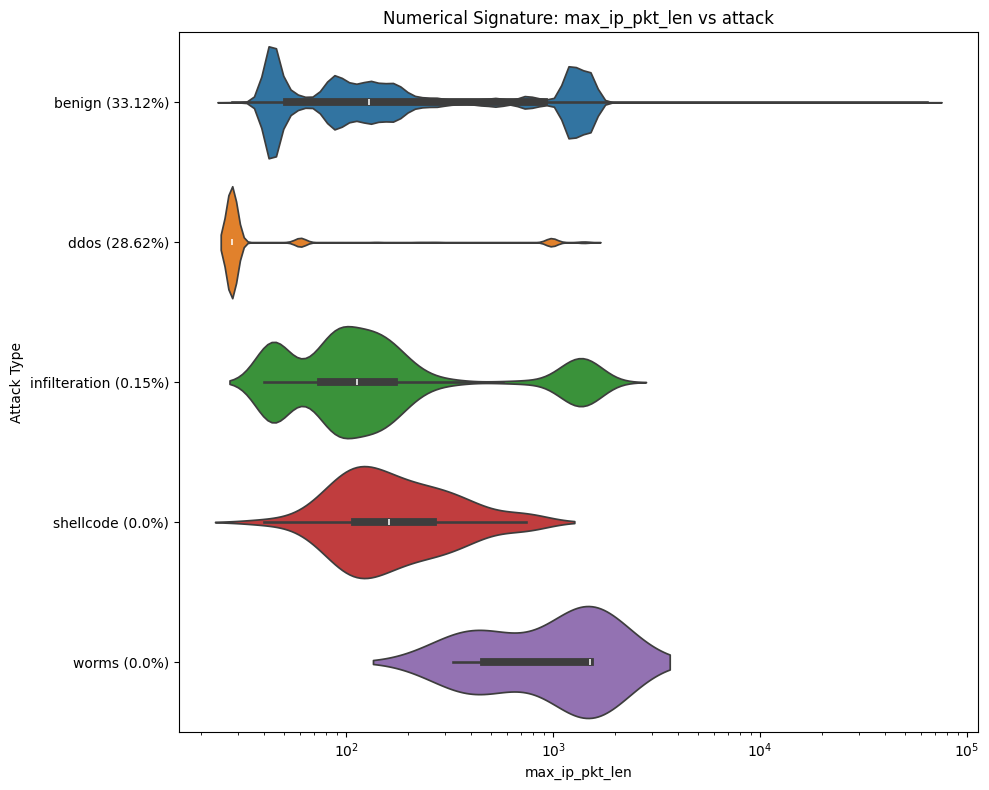

max_ip_pkt_len has HIGH ASSOCIATION with attack!


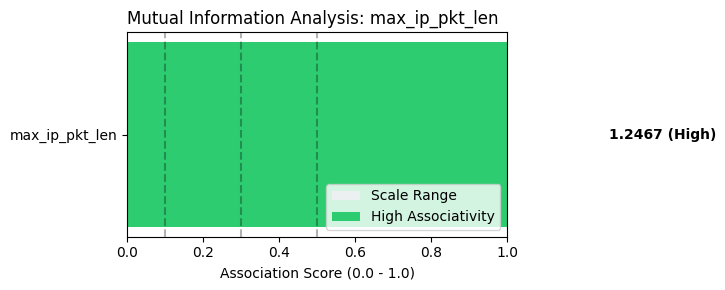

In [16]:
eND.analyze_statistical_significance_and_associativity(df, 'max_ip_pkt_len')

---
##### Explore src_to_dst_second_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Minimal association, VERY LARGE VALUES (TB)

src_to_dst_second_bytes IS statistically significant with attack!
Statistic: 1836797.3805
P-Val: 0.0000
P-Threshold: 0.0500



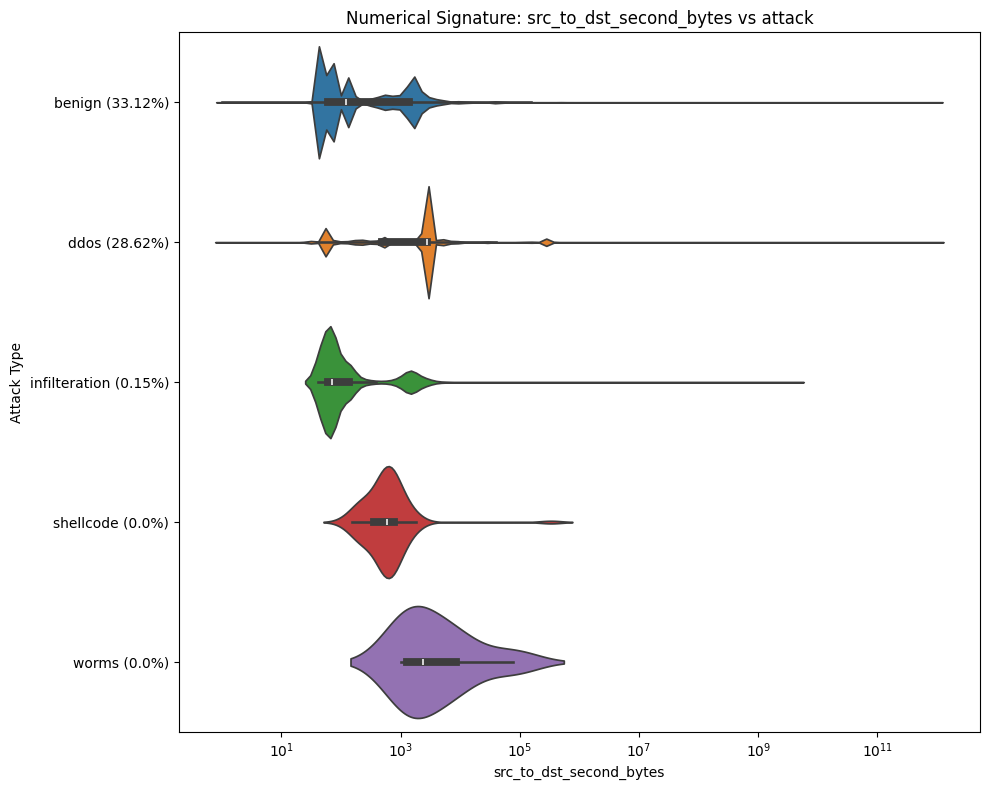

src_to_dst_second_bytes has MINIMAL ASSOCATION with attack!


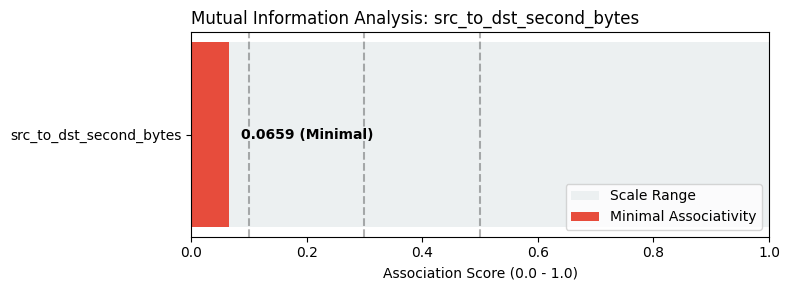

In [3]:
eND.analyze_statistical_significance_and_associativity(df, 'src_to_dst_second_bytes')

---
##### Explore dst_to_src_second_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Zero association

dst_to_src_second_bytes IS statistically significant with attack!
Statistic: 1758680.3400
P-Val: 0.0000
P-Threshold: 0.0500



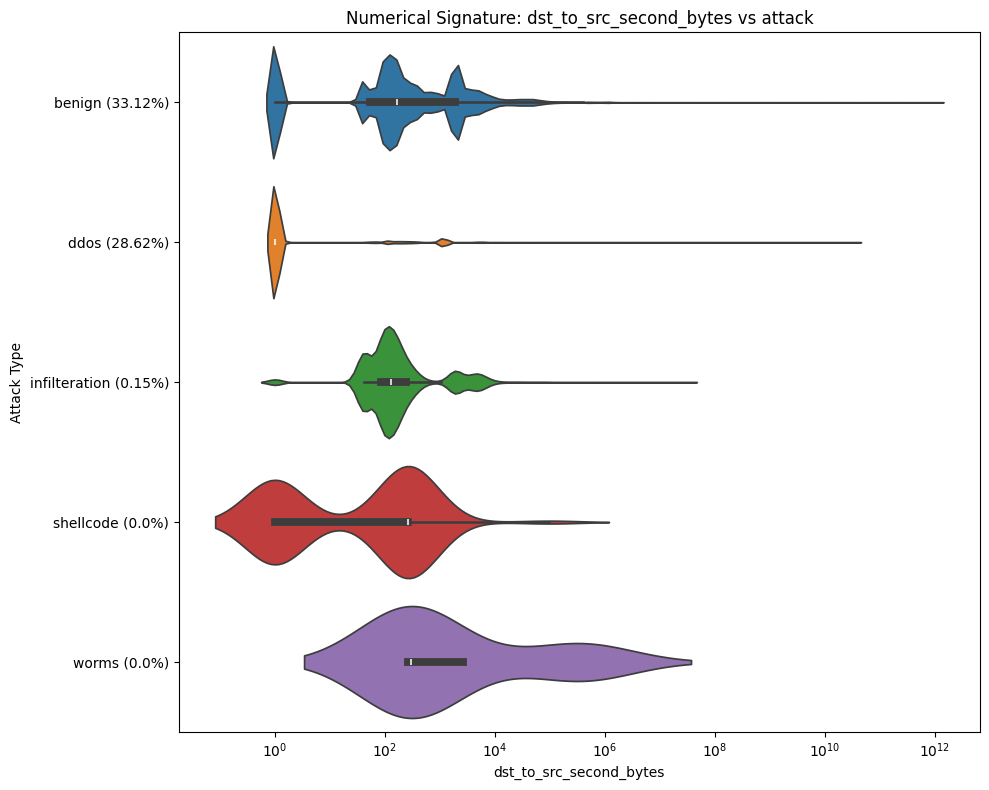

dst_to_src_second_bytes has MINIMAL ASSOCATION with attack!


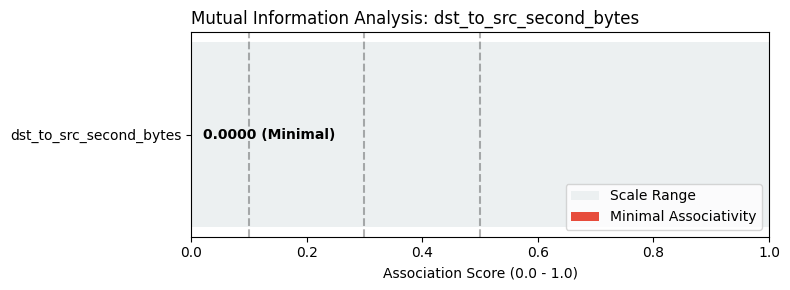

In [4]:
eND.analyze_statistical_significance_and_associativity(df, 'dst_to_src_second_bytes')

---
##### Explore retransmitted_in_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Low association

retransmitted_in_bytes IS statistically significant with attack!
Statistic: 413657.8153
P-Val: 0.0000
P-Threshold: 0.0500



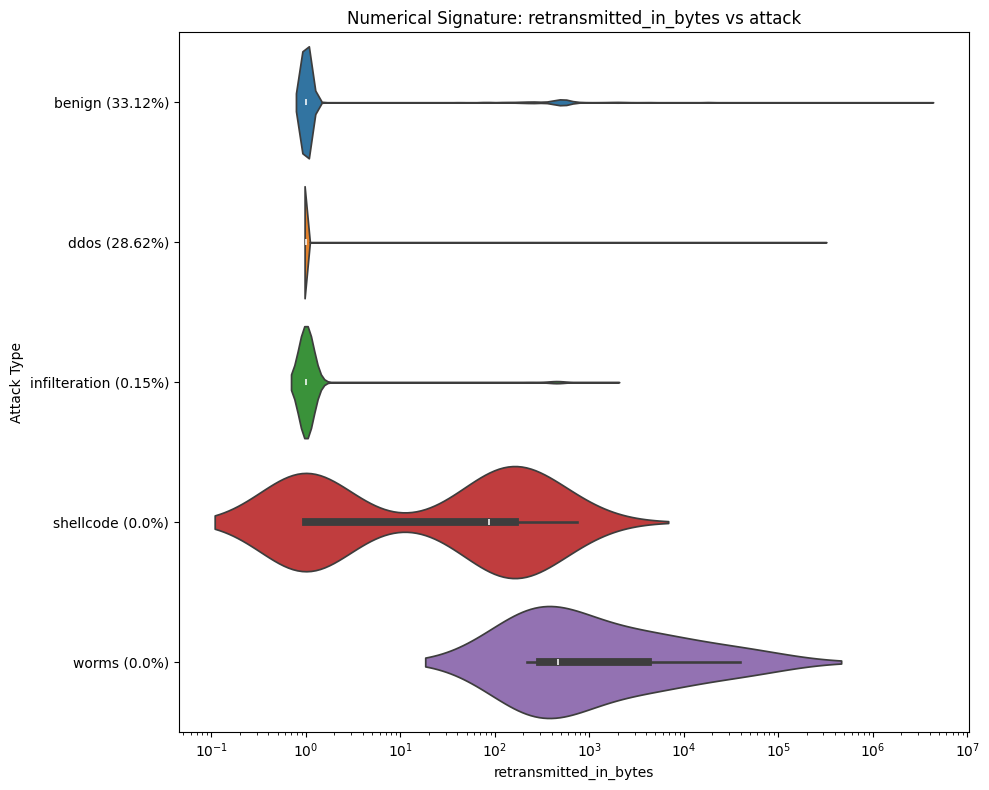

retransmitted_in_bytes has LOW ASSOCATION with attack!


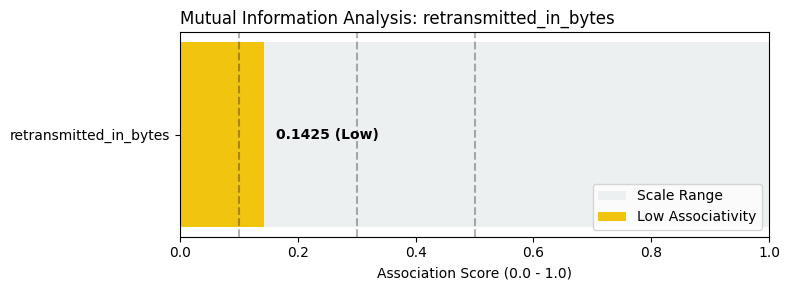

In [5]:
eND.analyze_statistical_significance_and_associativity(df, 'retransmitted_in_bytes')

---
##### Explore retransmitted_in_pkts

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Low association

retransmitted_in_pkts IS statistically significant with attack!
Statistic: 412214.7941
P-Val: 0.0000
P-Threshold: 0.0500



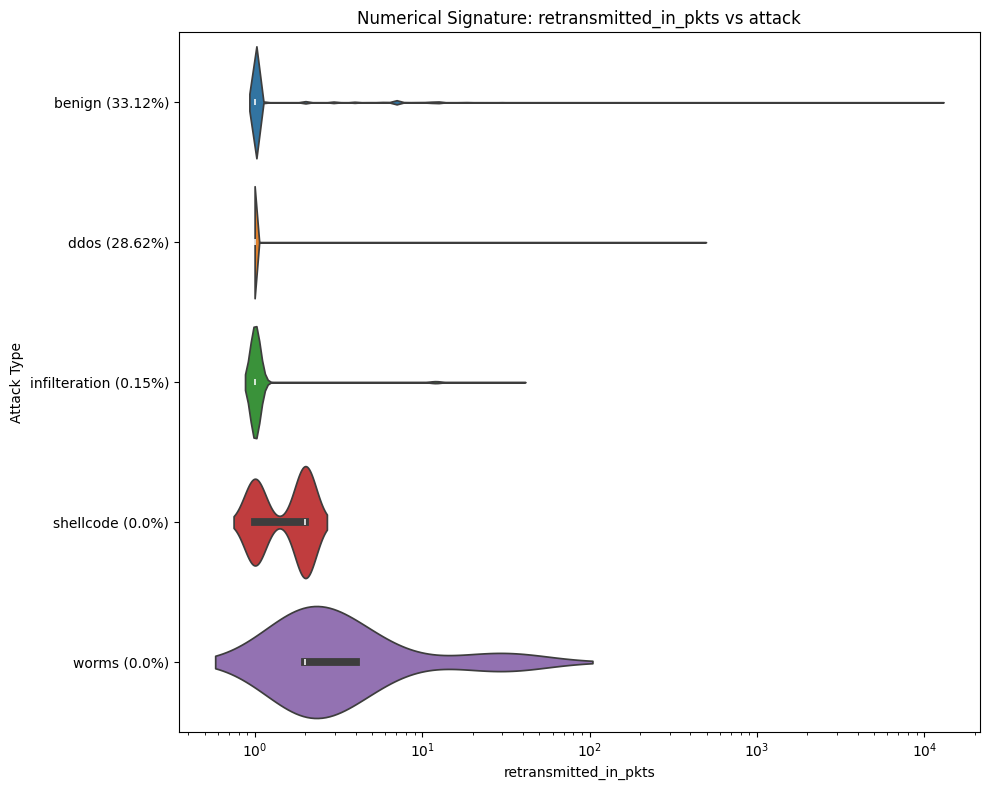

retransmitted_in_pkts has LOW ASSOCATION with attack!


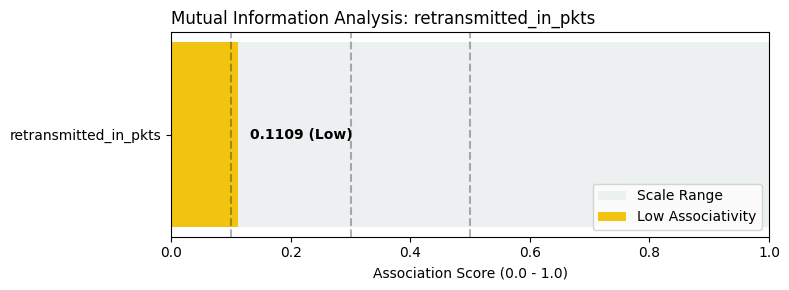

In [6]:
eND.analyze_statistical_significance_and_associativity(df, 'retransmitted_in_pkts')

---
##### Explore retransmitted_out_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Minimal association

retransmitted_out_bytes IS statistically significant with attack!
Statistic: 194427.0775
P-Val: 0.0000
P-Threshold: 0.0500



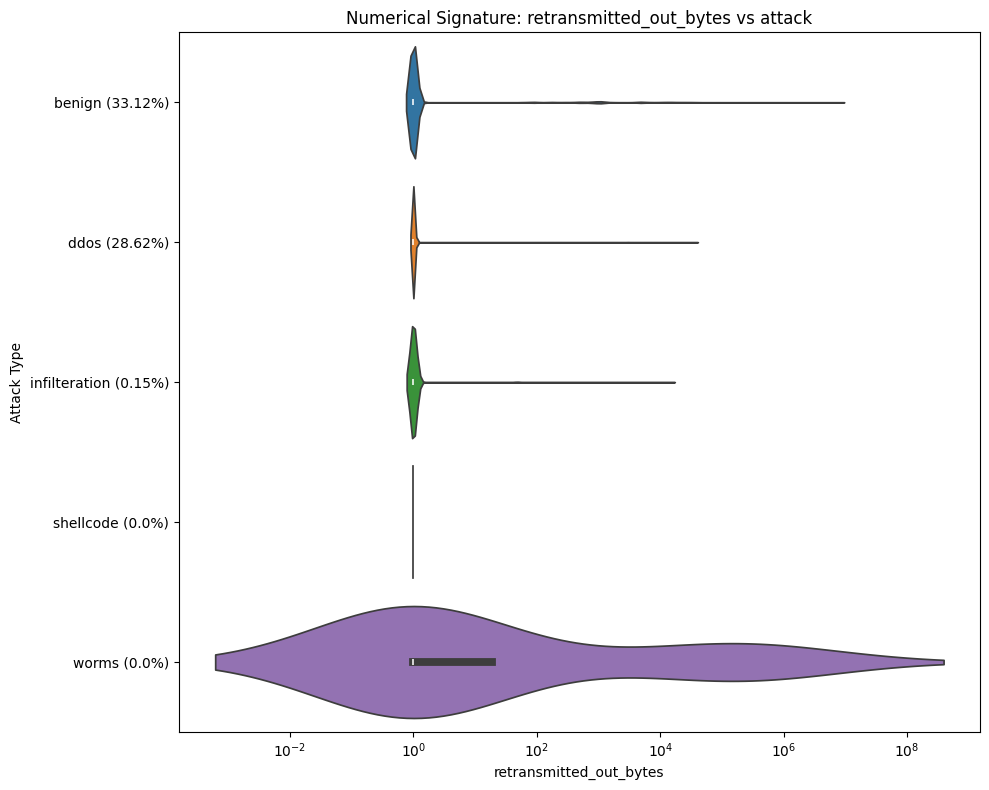

retransmitted_out_bytes has MINIMAL ASSOCATION with attack!


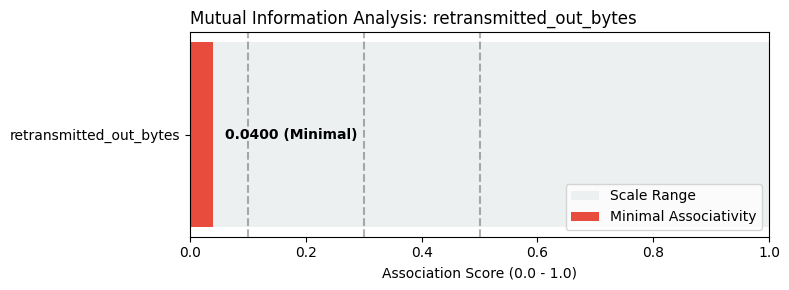

In [7]:
eND.analyze_statistical_significance_and_associativity(df, 'retransmitted_out_bytes')

---
##### Explore retransmitted_out_pkts

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Minimal association

retransmitted_out_pkts IS statistically significant with attack!
Statistic: 195186.5665
P-Val: 0.0000
P-Threshold: 0.0500



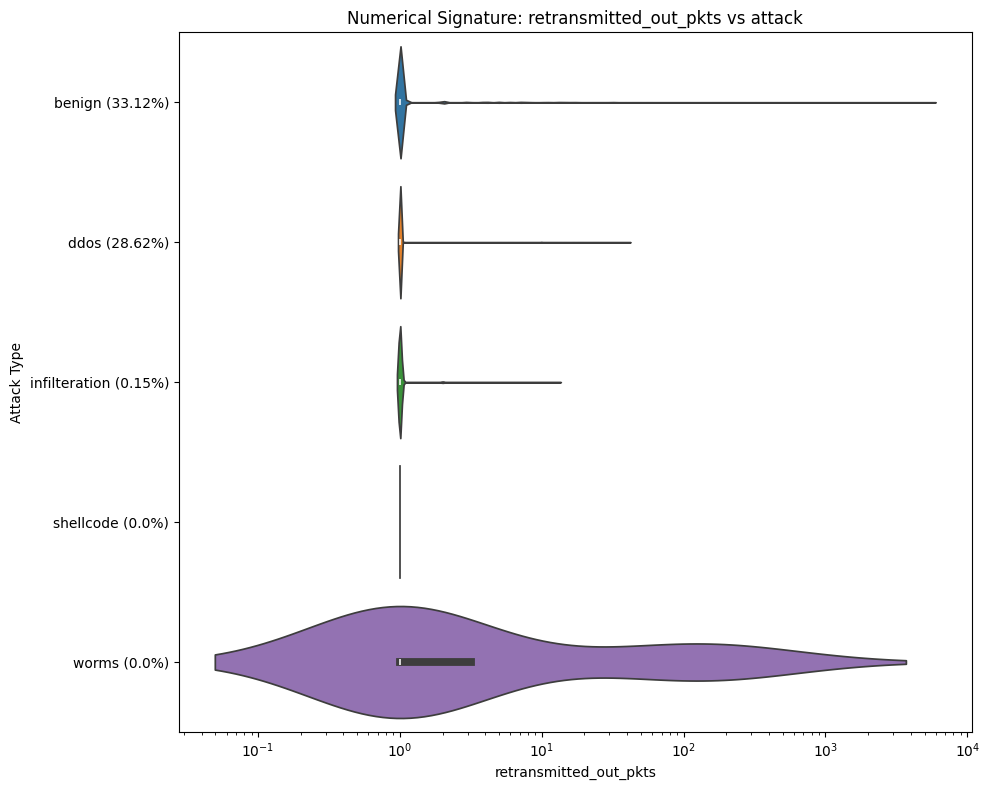

retransmitted_out_pkts has MINIMAL ASSOCATION with attack!


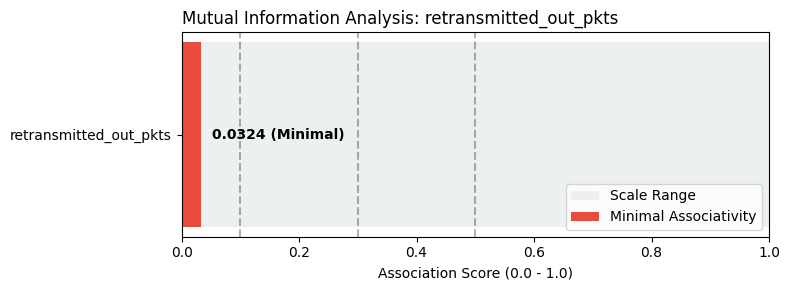

In [8]:
eND.analyze_statistical_significance_and_associativity(df, 'retransmitted_out_pkts')

---
##### Explore src_to_dst_avg_throughput

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

src_to_dst_avg_throughput IS statistically significant with attack!
Statistic: 1829066.6088
P-Val: 0.0000
P-Threshold: 0.0500



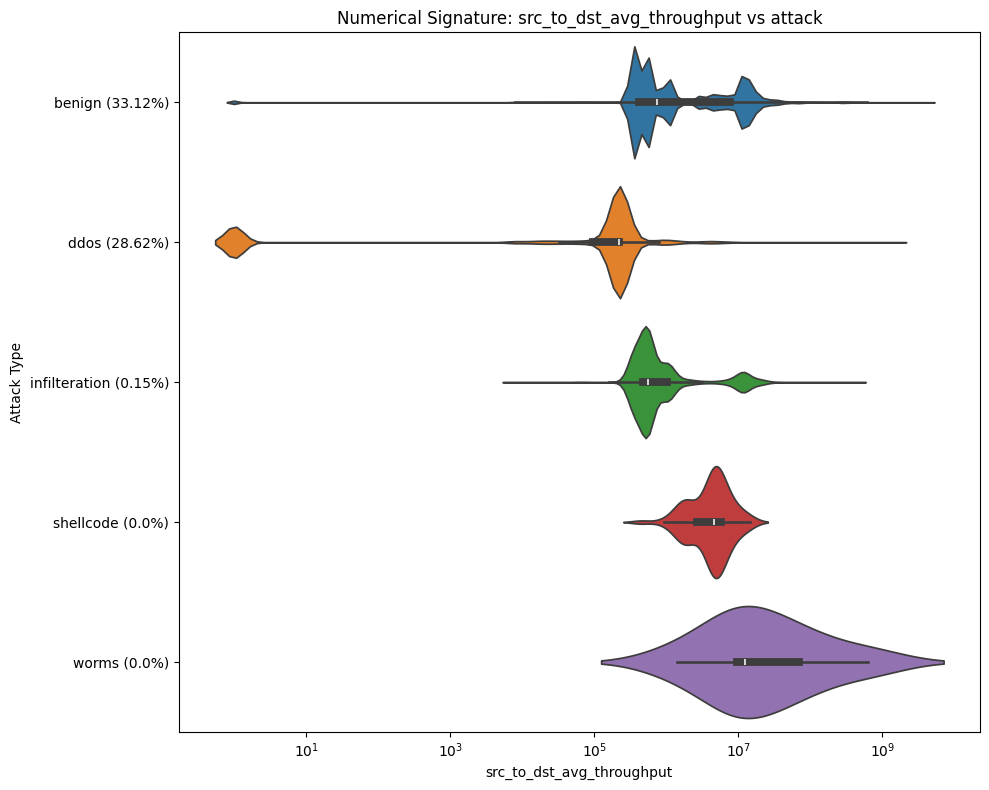

src_to_dst_avg_throughput has HIGH ASSOCIATION with attack!


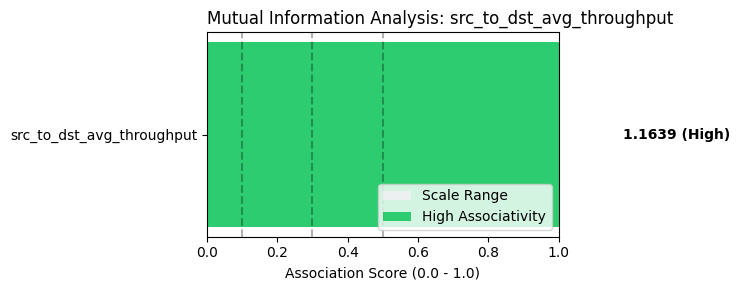

In [9]:
eND.analyze_statistical_significance_and_associativity(df, 'src_to_dst_avg_throughput')

---
##### Explore dst_to_src_avg_throughput

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- High association, likely similar info with src_to_dst_avg_throughput

dst_to_src_avg_throughput IS statistically significant with attack!
Statistic: 2012186.6375
P-Val: 0.0000
P-Threshold: 0.0500



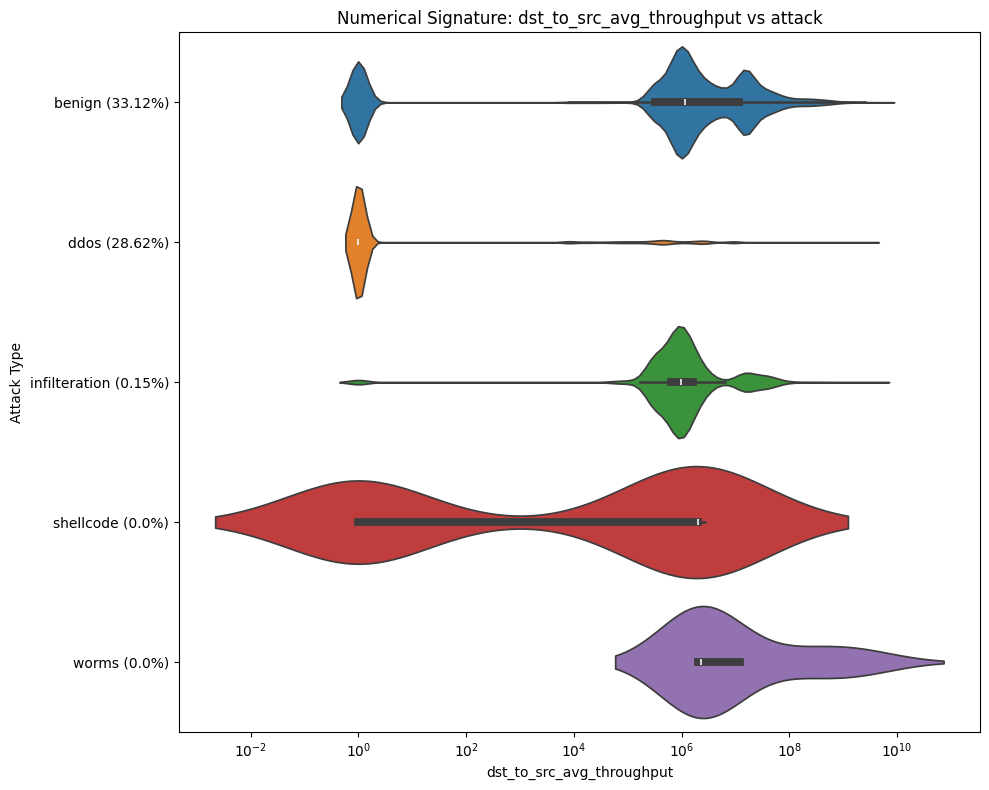

dst_to_src_avg_throughput has HIGH ASSOCIATION with attack!


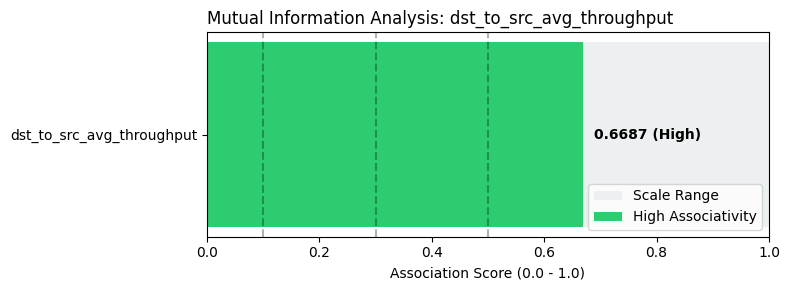

In [10]:
eND.analyze_statistical_significance_and_associativity(df, 'dst_to_src_avg_throughput')

---
##### Explore num_pkts_up_to_128_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

num_pkts_up_to_128_bytes IS statistically significant with attack!
Statistic: 1886365.5625
P-Val: 0.0000
P-Threshold: 0.0500



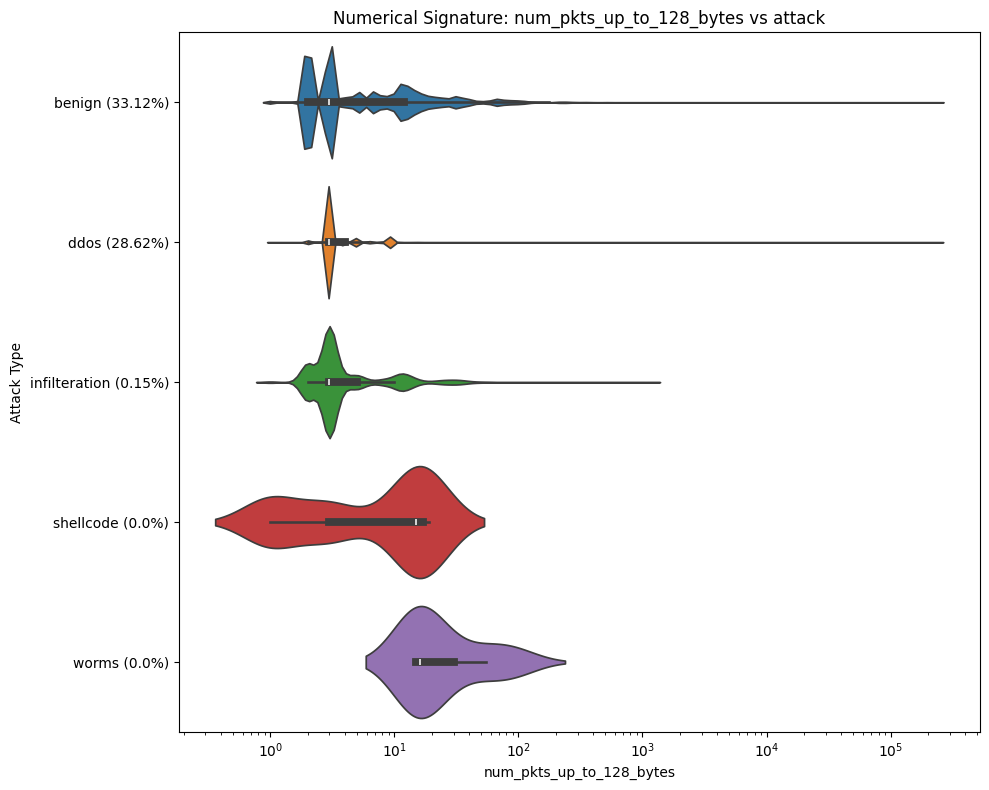

num_pkts_up_to_128_bytes has HIGH ASSOCIATION with attack!


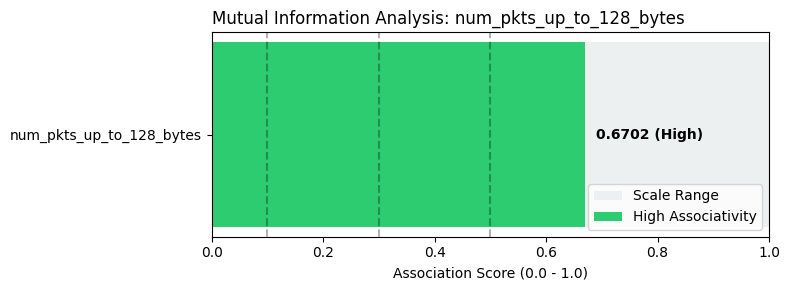

In [11]:
eND.analyze_statistical_significance_and_associativity(df, 'num_pkts_up_to_128_bytes')

---
##### Explore num_pkts_128_to_256_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- Mod association, distribution appears to have a trend

num_pkts_128_to_256_bytes IS statistically significant with attack!
Statistic: 1869970.8601
P-Val: 0.0000
P-Threshold: 0.0500



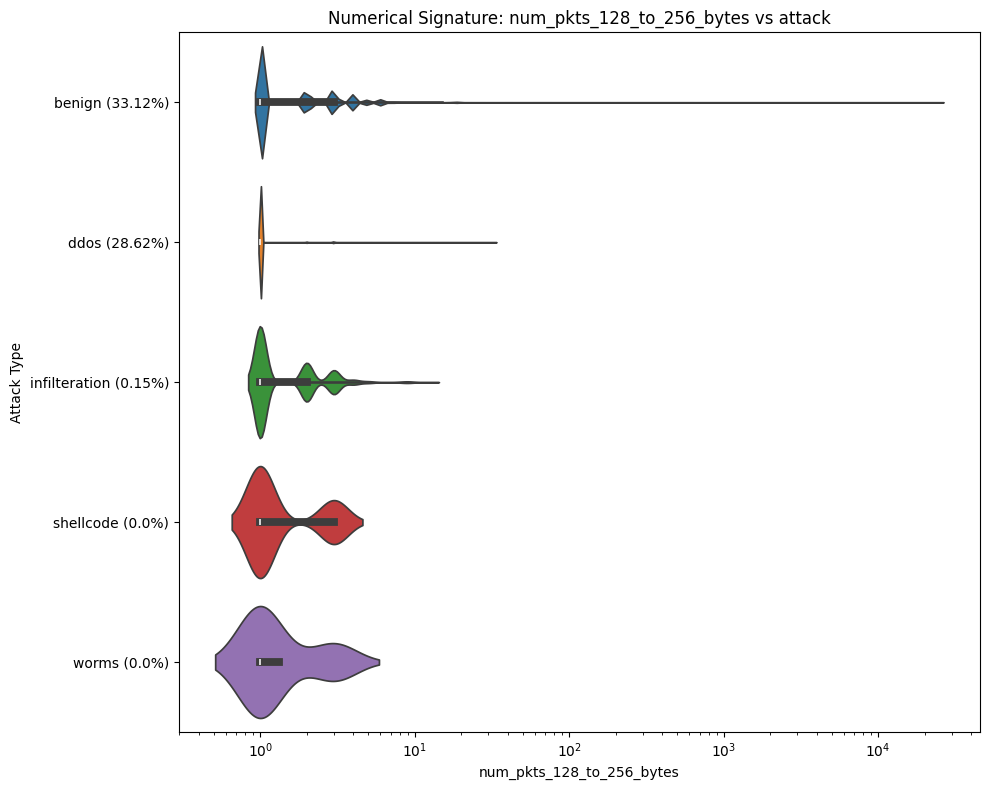

num_pkts_128_to_256_bytes is MODERATE ASSOCIATION with attack!


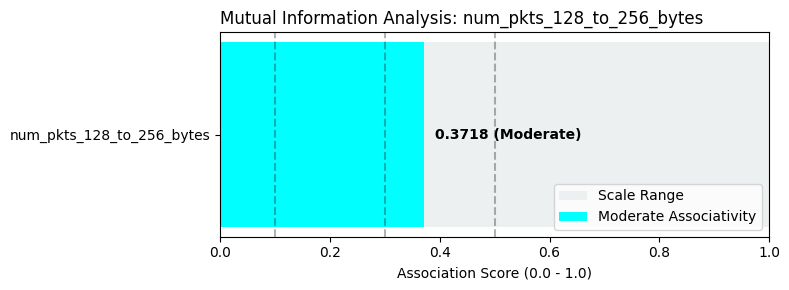

In [12]:
eND.analyze_statistical_significance_and_associativity(df, 'num_pkts_128_to_256_bytes')

---
##### Explore num_pkts_256_to_512_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Minimal association

num_pkts_256_to_512_bytes IS statistically significant with attack!
Statistic: 516553.5190
P-Val: 0.0000
P-Threshold: 0.0500



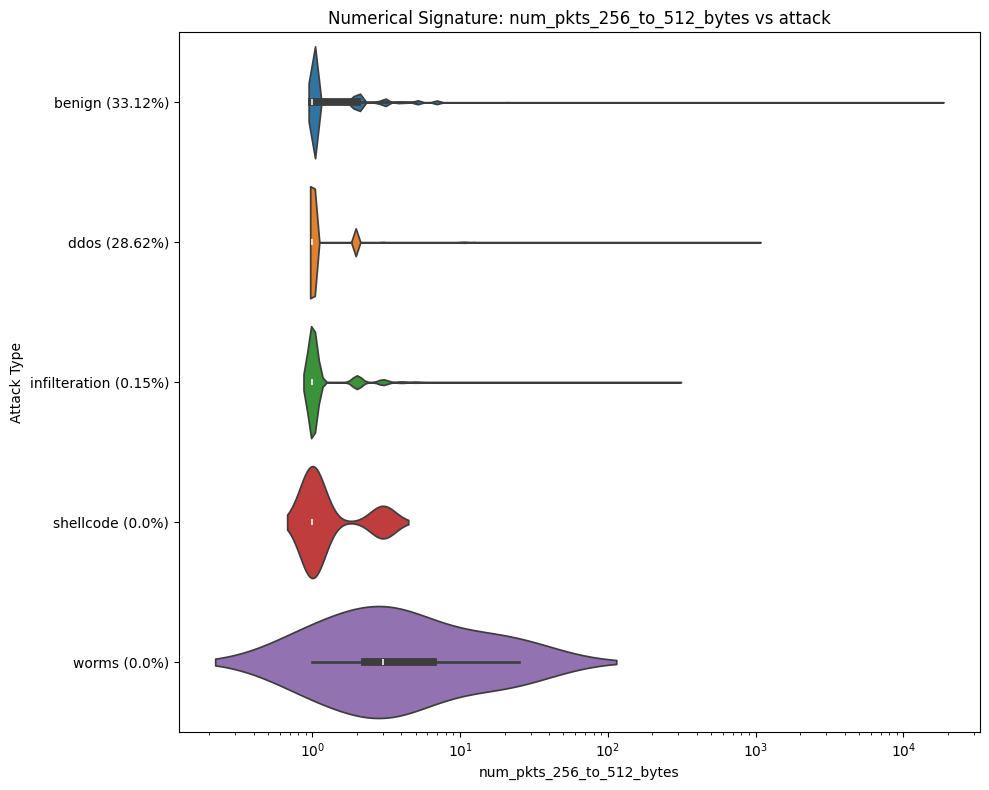

num_pkts_256_to_512_bytes has MINIMAL ASSOCATION with attack!


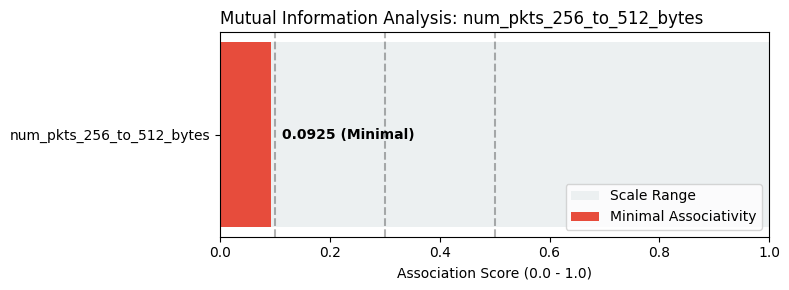

In [13]:
eND.analyze_statistical_significance_and_associativity(df, 'num_pkts_256_to_512_bytes')

---
##### Explore num_pkts_512_to_1024_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Minimal association

num_pkts_512_to_1024_bytes IS statistically significant with attack!
Statistic: 469986.3169
P-Val: 0.0000
P-Threshold: 0.0500



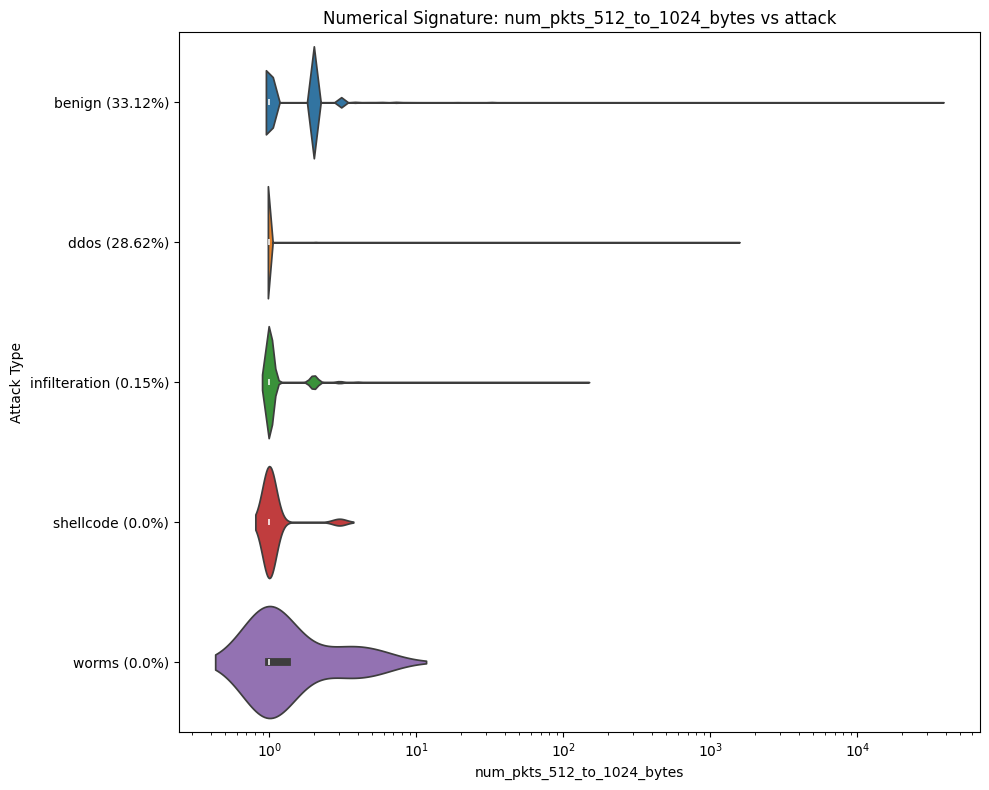

num_pkts_512_to_1024_bytes has MINIMAL ASSOCATION with attack!


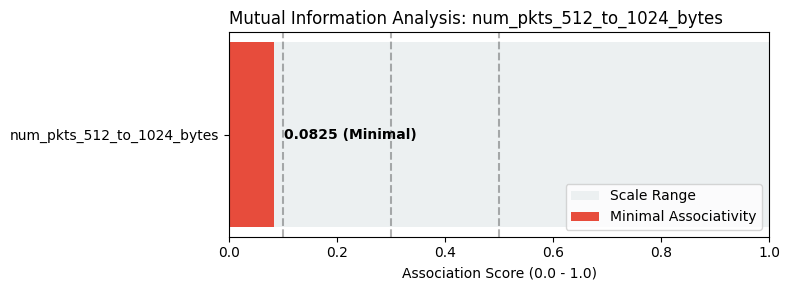

In [14]:
eND.analyze_statistical_significance_and_associativity(df, 'num_pkts_512_to_1024_bytes')

---
##### Explore num_pkts_1024_to_1514_bytes

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Low association

num_pkts_1024_to_1514_bytes IS statistically significant with attack!
Statistic: 725147.7971
P-Val: 0.0000
P-Threshold: 0.0500



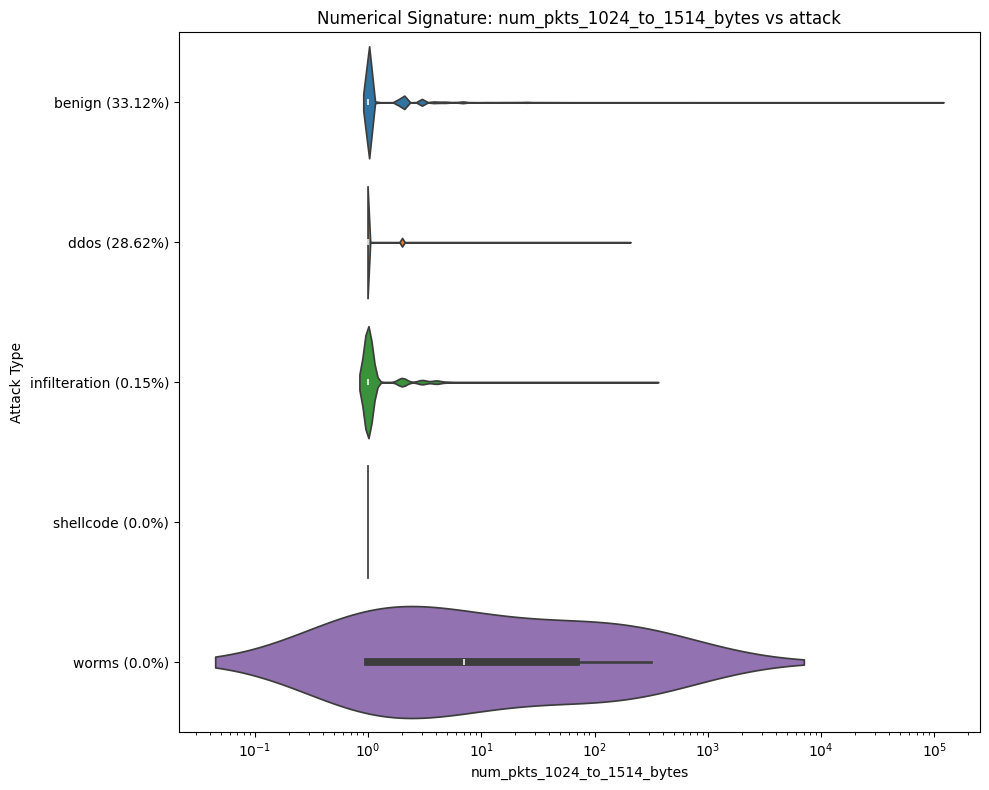

num_pkts_1024_to_1514_bytes has LOW ASSOCATION with attack!


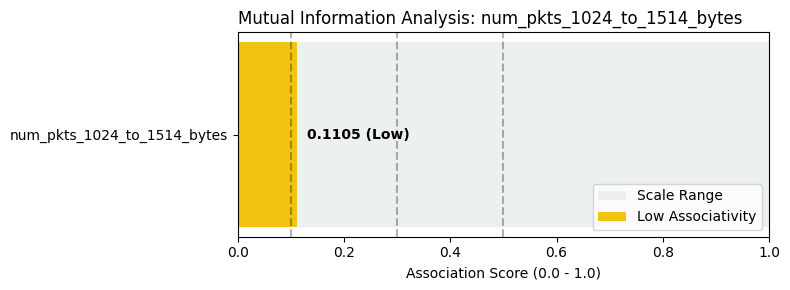

In [15]:
eND.analyze_statistical_significance_and_associativity(df, 'num_pkts_1024_to_1514_bytes')

---
##### Explore tcp_win_max_in

- [Back to Table of Contents](#table-of-contents)

VERDICT: KEEP

MISC: 
- High association, distribution appears to have a trend

tcp_win_max_in IS statistically significant with attack!
Statistic: 943921.8662
P-Val: 0.0000
P-Threshold: 0.0500



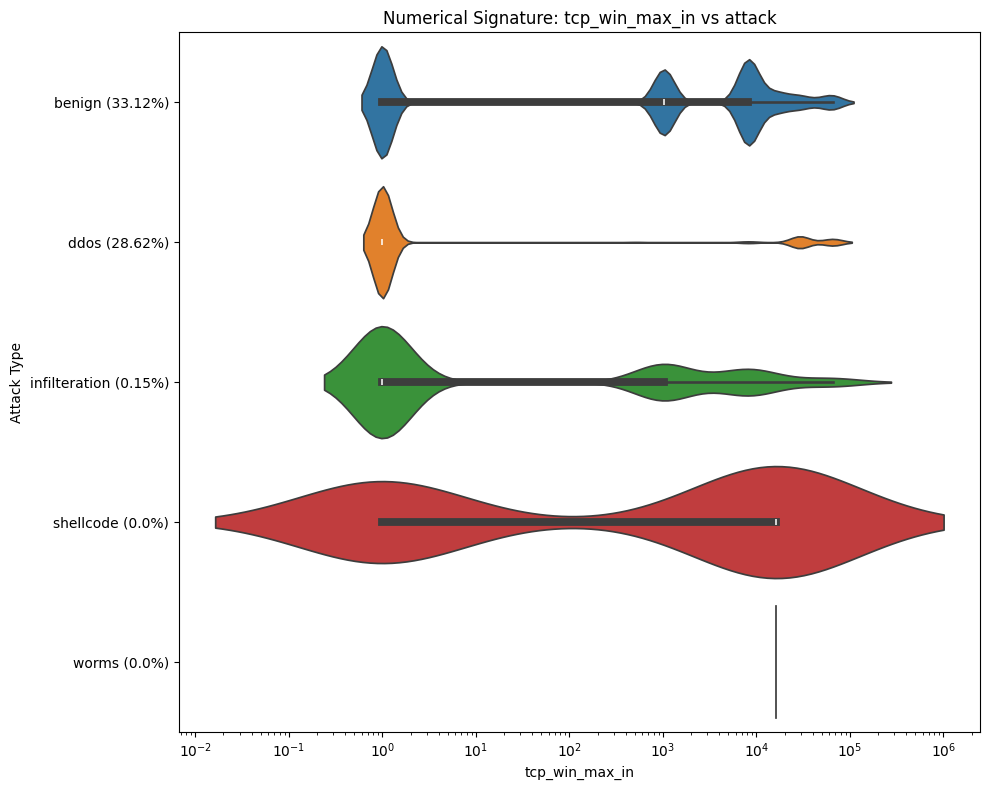

tcp_win_max_in has HIGH ASSOCIATION with attack!


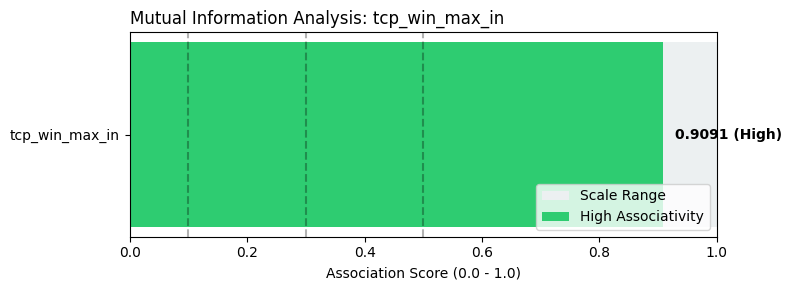

In [16]:
eND.analyze_statistical_significance_and_associativity(df, 'tcp_win_max_in')

---
##### Explore tcp_win_max_out

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Mod association, likely similar information to tcp_win_max_in

tcp_win_max_out IS statistically significant with attack!
Statistic: 855178.8415
P-Val: 0.0000
P-Threshold: 0.0500



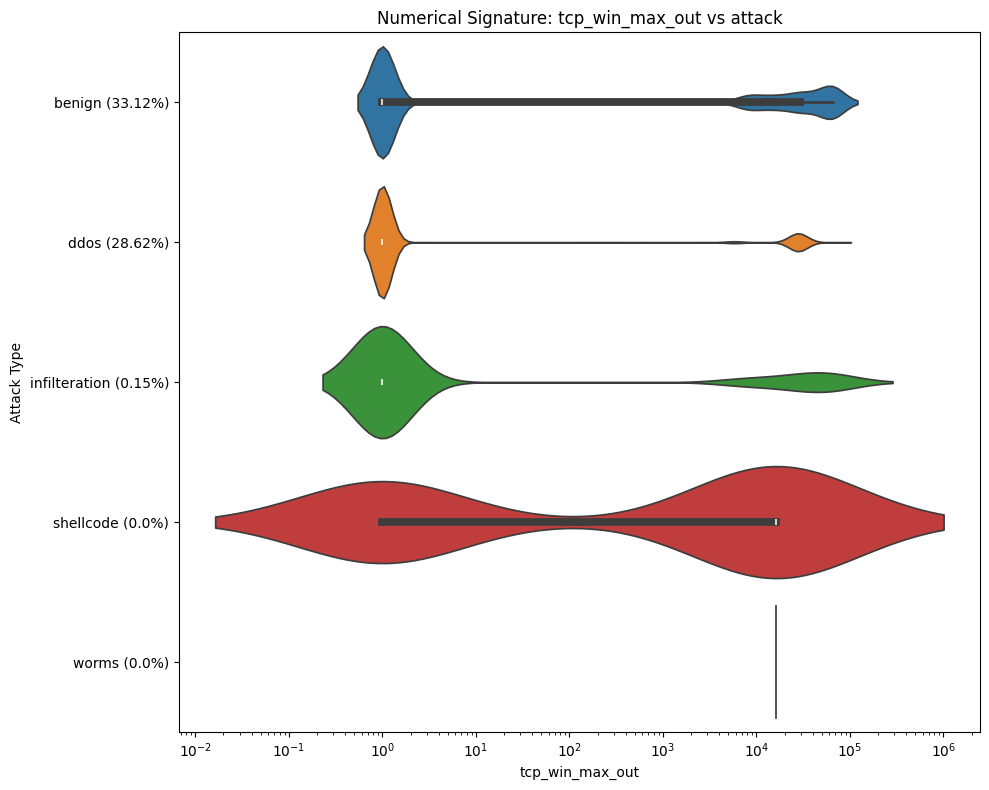

tcp_win_max_out is MODERATE ASSOCIATION with attack!


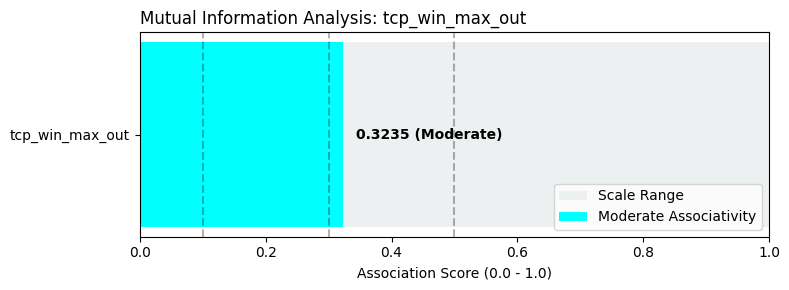

In [17]:
eND.analyze_statistical_significance_and_associativity(df, 'tcp_win_max_out')

---
##### Explore icmp_type

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Low association, distribution biased

icmp_type IS statistically significant with attack!
Statistic: 2542655.0238
P-Val: 0.0000
P-Threshold: 0.0500


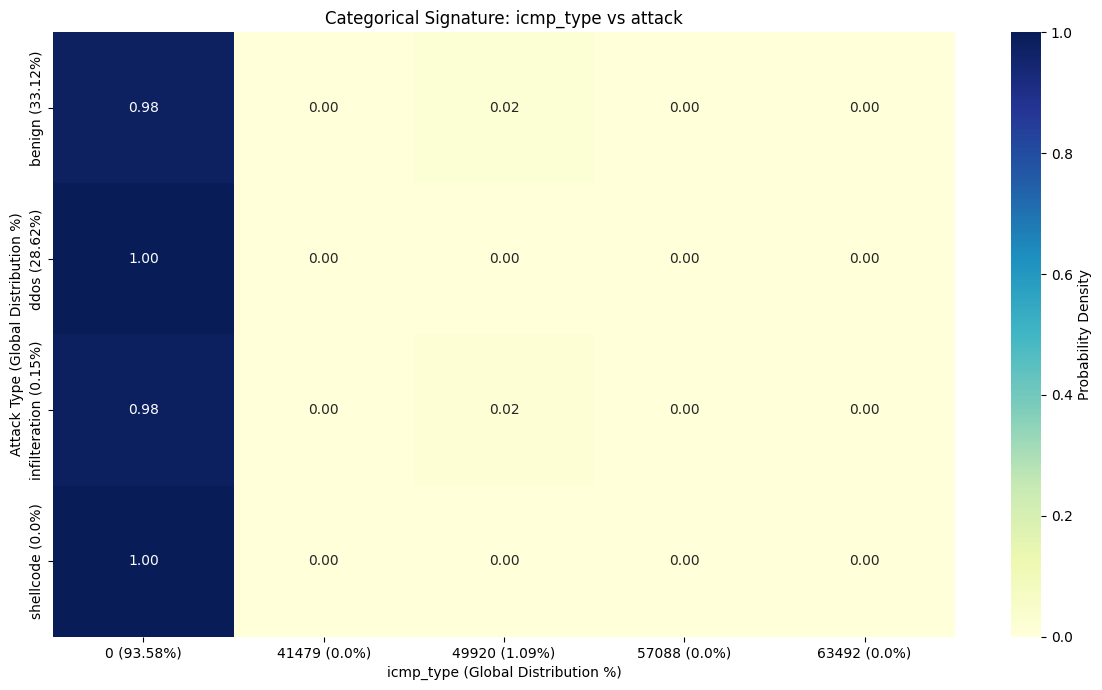

icmp_type has LOW ASSOCATION with attack!


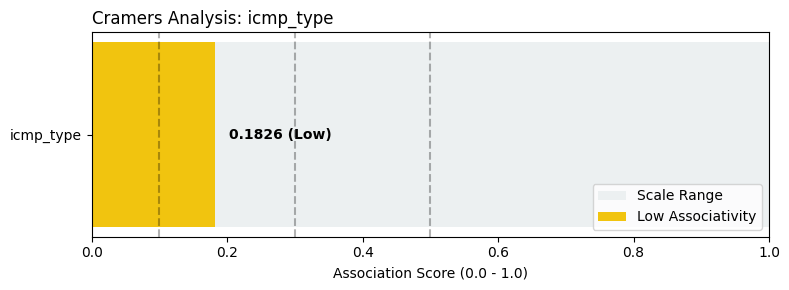

In [18]:
eND.analyze_statistical_significance_and_associativity(df, 'icmp_type', is_object_feature=True)

---
##### Explore icmp_ipv4_type

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Low association, distribution biased

icmp_ipv4_type IS statistically significant with attack!
Statistic: 2090553.5306
P-Val: 0.0000
P-Threshold: 0.0500


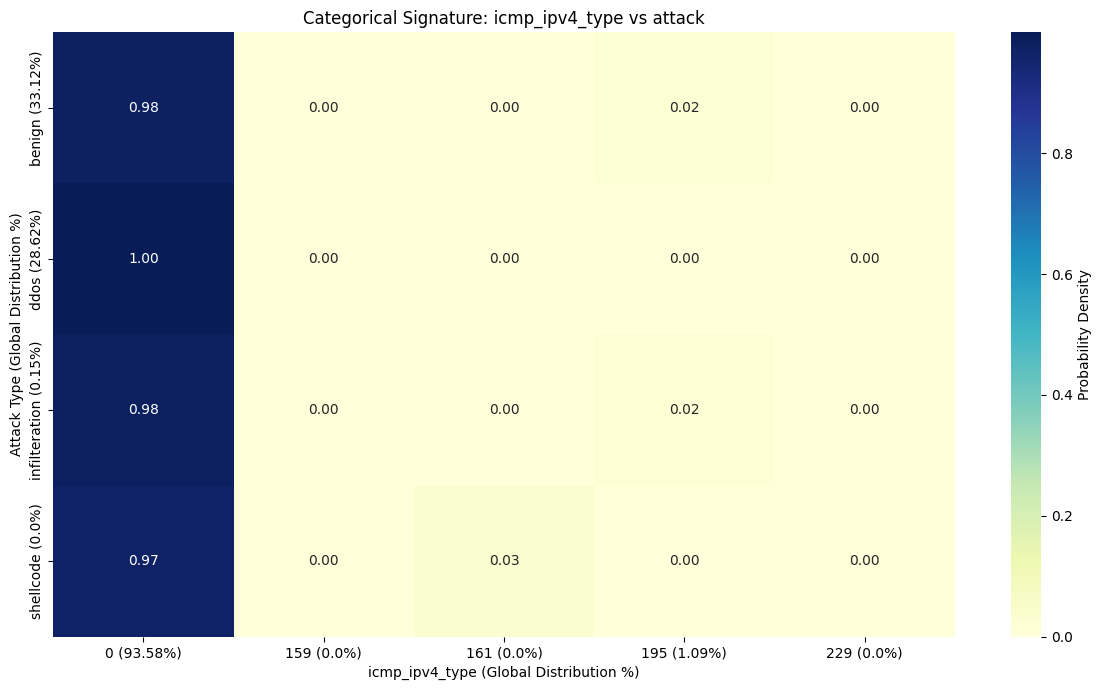

icmp_ipv4_type has LOW ASSOCATION with attack!


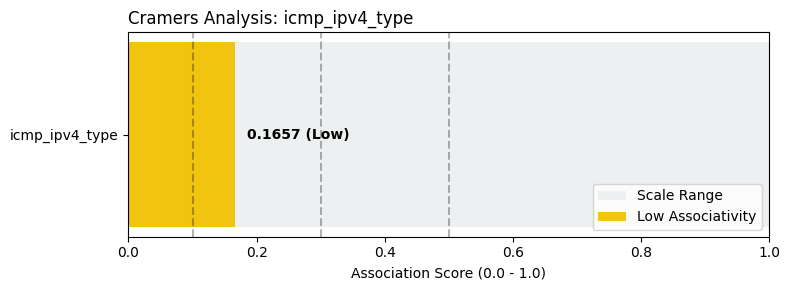

In [19]:
eND.analyze_statistical_significance_and_associativity(df, 'icmp_ipv4_type', is_object_feature=True)

---
##### Explore dns_query_id

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Low association, distribution biased

dns_query_id IS statistically significant with attack!
Statistic: 2598623.4426
P-Val: 0.0000
P-Threshold: 0.0500


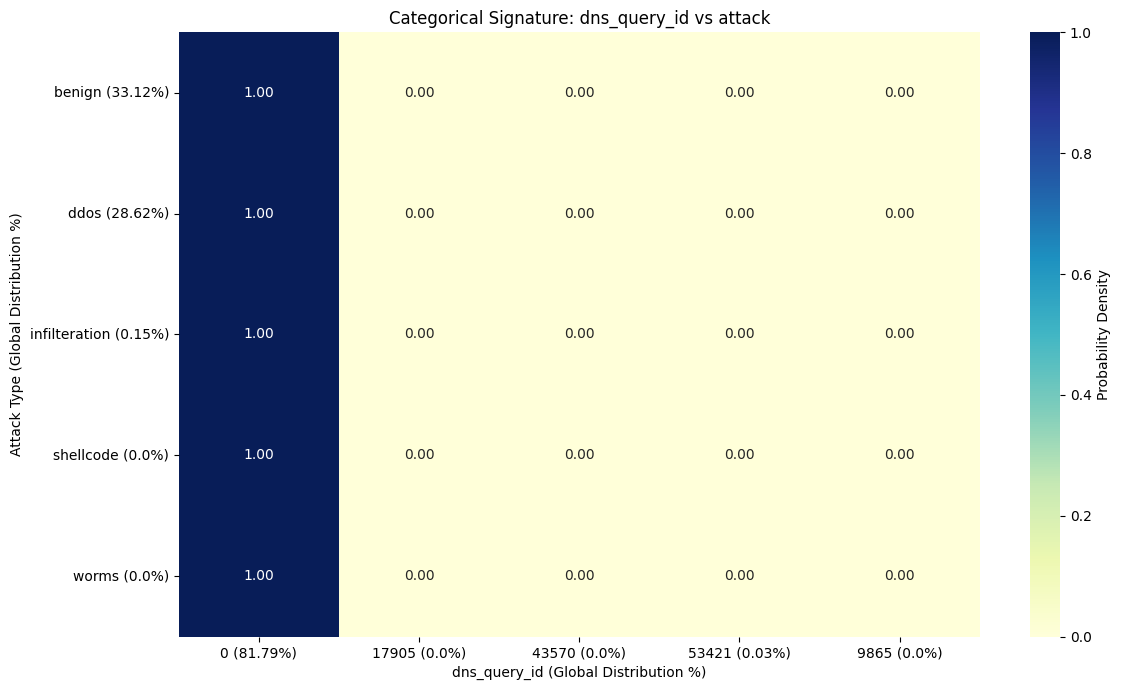

dns_query_id has LOW ASSOCATION with attack!


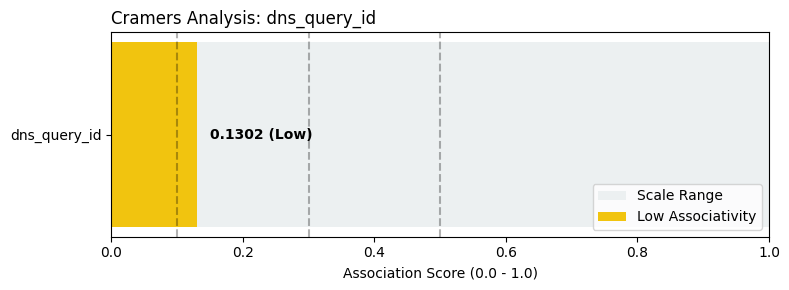

In [20]:
eND.analyze_statistical_significance_and_associativity(df, 'dns_query_id', is_object_feature=True)

---
##### Explore dns_query_type

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Low association, distribution biased

dns_query_type IS statistically significant with attack!
Statistic: 1279381.8835
P-Val: 0.0000
P-Threshold: 0.0500


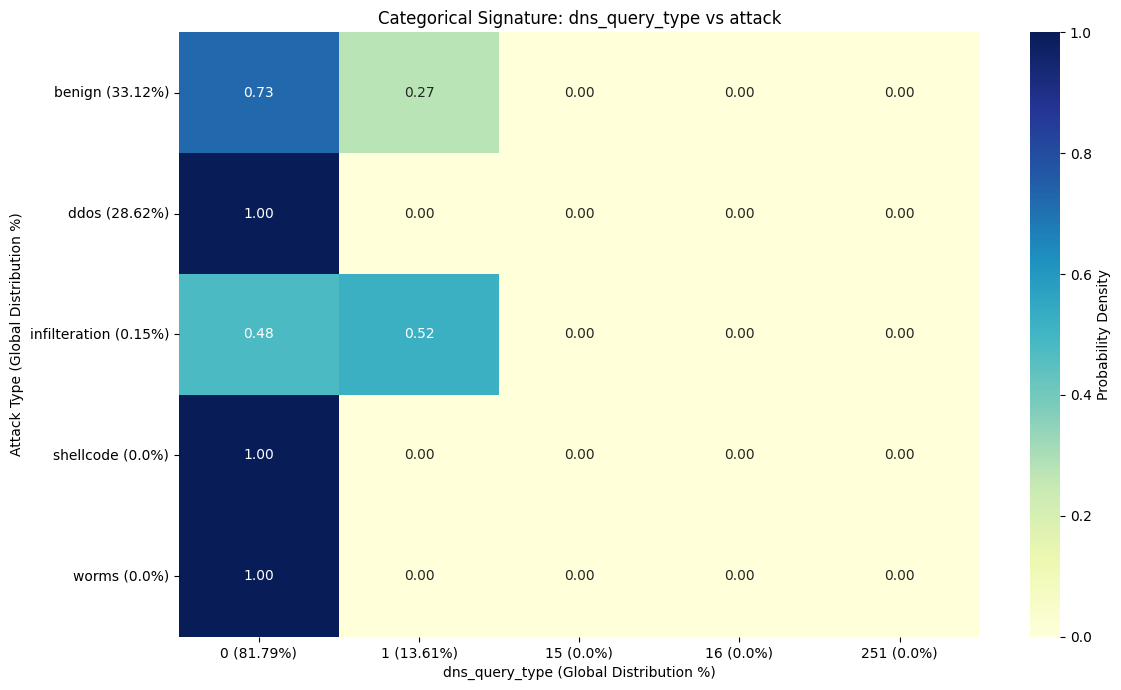

dns_query_type has LOW ASSOCATION with attack!


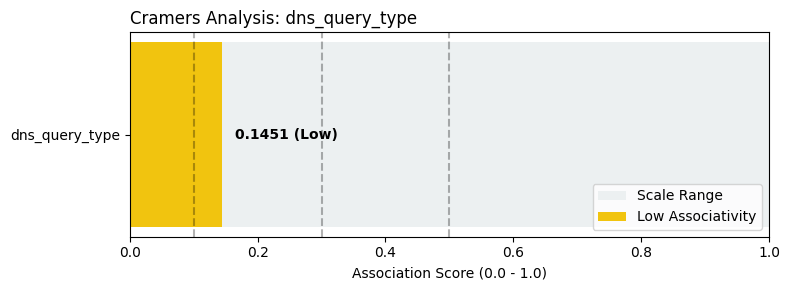

In [21]:
eND.analyze_statistical_significance_and_associativity(df, 'dns_query_type', is_object_feature=True)

---
##### Explore dns_ttl_answer

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Low association, distribution biased

dns_ttl_answer IS statistically significant with attack!
Statistic: 858813.1841
P-Val: 0.0000
P-Threshold: 0.0500



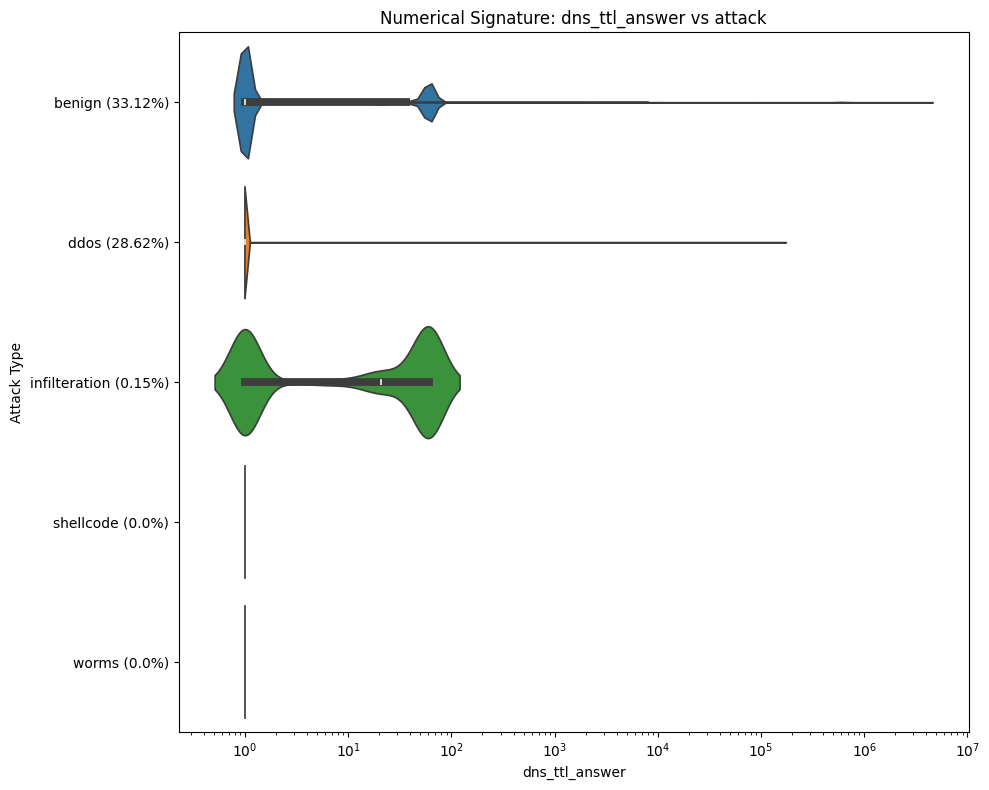

dns_ttl_answer has LOW ASSOCATION with attack!


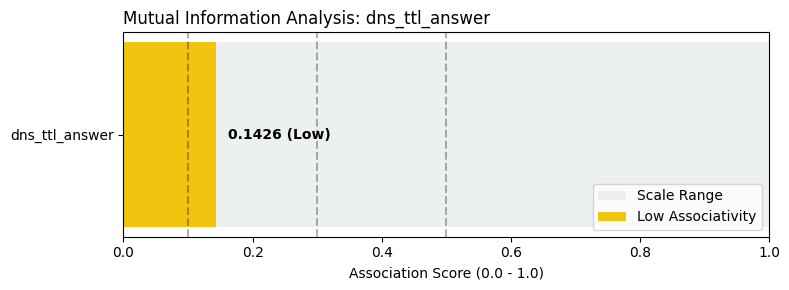

In [22]:
eND.analyze_statistical_significance_and_associativity(df, 'dns_ttl_answer')

---
##### Explore ftp_command_ret_code

- [Back to Table of Contents](#table-of-contents)

VERDICT: REMOVE

MISC: 
- Minimal association, distribution biased

ftp_command_ret_code IS statistically significant with attack!
Statistic: 571399.5612
P-Val: 0.0000
P-Threshold: 0.0500


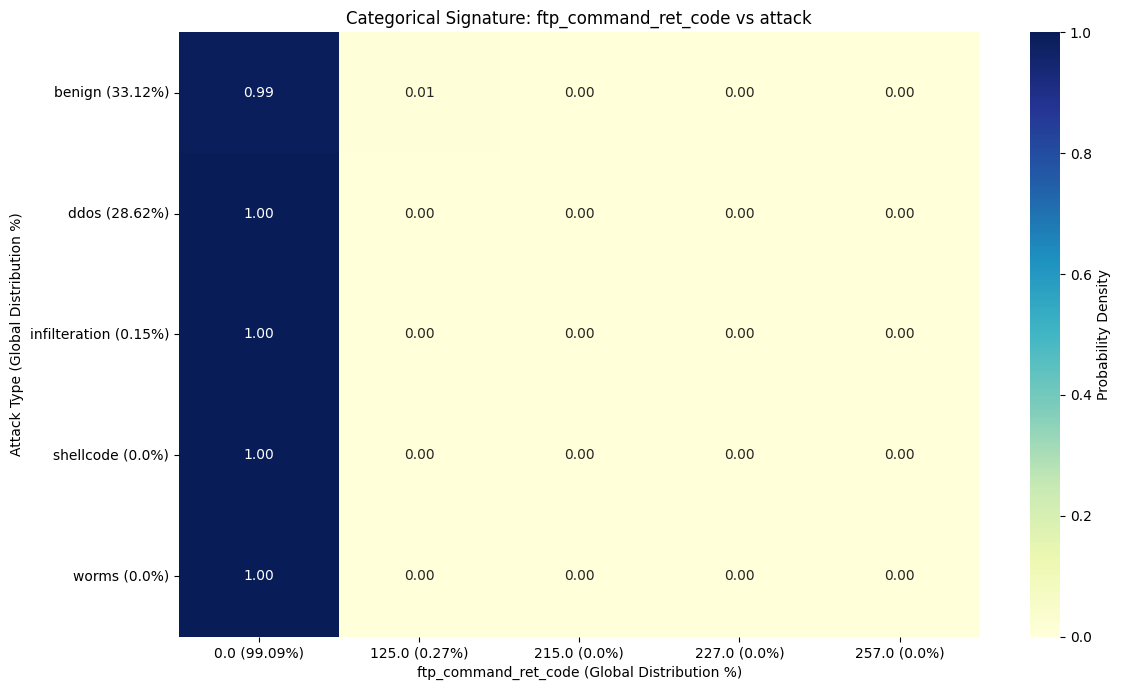

ftp_command_ret_code has MINIMAL ASSOCATION with attack!


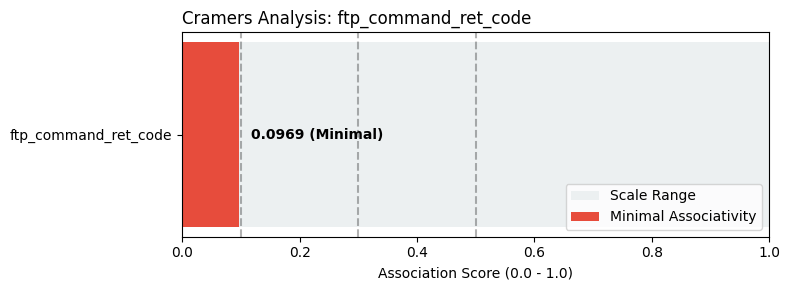

In [23]:
eND.analyze_statistical_significance_and_associativity(df, 'ftp_command_ret_code', is_object_feature=True)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Final Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>

In [3]:
# First lets reduce, encode, and scale cols where necessary
reduced_df = eND.preprocess_normal_data(df)

In [6]:
# Export the fully prepared dataset for model training and testing
w.export_to_parquet(reduced_df, 'datasets/prepared_normal_short.parquet')

Attempting to export Pandas Dataframe to datasets/prepared_normal_short.parquet...
Successfully exported Pandas Dataframe to datasets/prepared_normal_short.parquet!


| Feature Name | Dtype | Example | Description |
| :--- | :--- | :--- | :--- |
| **in_bytes** | `float64` | -0.577, -0.428, -0.523 | Log-transformed and robust-scaled incoming bytes transferred from source to destination. |
| **out_bytes** | `float64` | 0.0, 0.739, 1.321 | Log-transformed and robust-scaled outgoing bytes transferred from destination back to source. |
| **flow_duration_milliseconds** | `float64` | -0.999, 1.451e-05 | Log-transformed and robust-scaled total elapsed time of the flow in milliseconds. |
| **duration_in** | `float64` | -0.020, 0.891, 0.666 | Robust-scaled duration of the active flow in the incoming direction. |
| **min_ttl** | `float64` | -1.0, 0.0, 0.562 | Robust-scaled minimum Time-to-Live (TTL) value observed in the flow. |
| **max_ttl** | `float64` | -1.0, 0.0, 0.562 | Robust-scaled maximum Time-to-Live (TTL) value observed in the flow. |
| **longest_flow_pkt** | `float64` | -0.56, -0.72, -0.52 | Robust-scaled size (in bytes) of the largest packet observed in the flow. |
| **shortest_flow_pkt** | `float64` | 0.0, -0.551, -0.137 | Robust-scaled size (in bytes) of the smallest packet observed in the flow. |
| **max_ip_pkt_len** | `float64` | -0.56, -0.72, -0.52 | Robust-scaled maximum IP packet length observed in the flow. |
| **src_to_dst_avg_throughput** | `float64` | -0.242, -0.523, -0.188 | Log-transformed and robust-scaled average bits per second sent from source to destination. |
| **num_pkts_up_to_128_bytes** | `float64` | -0.333, 0.0, 5.666 | Robust-scaled count of packets in the flow with size ≤ 128 bytes. |
| **num_pkts_128_to_256_bytes** | `float64` | 0.0, 0.5, 1.0 | Robust-scaled count of packets in the flow with size between 128 and 256 bytes. |
| **tcp_win_max_in** | `float64` | 0.125, -0.125, 0.875 | Robust-scaled maximum TCP window size observed for incoming traffic. |
| **attack** | `str` | scanning, benign, ddos | Categorical name of the specific attack type (21 unique tags). |
| **target** | `int64` | 16, 2, 5 | Numerical integer mapping of the attack type for machine learning compatibility. |